# **Approaching the Etymologies of the Odyssey**

The topic of etymology is more complex than appears at first. Between morphology and semantic changes, tracing the transformation of a word requieres philological caution. There are cases in which, even taking that minute care of the philologist, there aren't a scholar consensus regarding a word's origin. 

A programatic approach that catches all the words in a sample with some precision is a daunting task. I attempted to do this here, using the most complete etymologycal dictionary in Egnlish and creating functions to assign their etymological label to each token in the six translations of the Odyssey. 

A notorious limitation of this first approach is that most of the etymologies in this six million plus entries dictionary(based on [Wiktionary:Etymology](https://en.wiktionary.org/wiki/Wiktionary:Etymology)) still are a recursive deadend in which a eng: word leads to the same eng: word. the silver lining is that this handicap is democratic, i.e., normally distributed across the translations, so they share the downside. 

**The road map**
* Getting the Odysseys and etimologies (loading data)
* Mapping words to their etymology
* Getting the word-etymology frequencies by book
    - Show distributions with plots
* Compare etymological distributions across authors
    - Scale the frequencies to minimize the effect zise of token lenght
    - Focus on the five most important: 
        - eng: English
        - enm: Middle English
        - ang: Anglo-Saxon
        - lat: Latin
        - xno: Old Norman
        - *plus:* `grc:` Ancient Greek (because of the Odyssey)
    - Compare authors side-by-side_
        - All roots: Fizgerald vs Wilson
        - All authors: ang & lat across books

**Future Version**

* Adding baseline: Woolf's *A Voyage Out*
* Hypothesis testing
    - ANOVA to compare multiple distributions
        * H0: There is NOT significant etymological differnece between the authors
        * H1: There is SIGNIFICANT etymological differnece between the authors


Melo's dictionary doesn't follow the expected etymological distribution of English, equal parts of **Latin**, **French** (Middle-French and Anglo-French/Anglo-Norman included), and **Germanic** (Old German, Old Norse, Anglo-Saxon included). This is because, as I mentioned above, in many cases following a word programmatically falls back to its English label. This is true of the dictionary's structure as it's true of my function. 

![English Roots](/Users/debr/English-Homer/assets/images/Origins_of_English_PieChart_2D.svg)



In [1]:
#### Other libraries
import sys
import os

import ast
from collections import Counter

import re
import nltk

import numpy as np
import pandas as pd

In [43]:
#### Visualization
sys.path.append('/Users/debr/English-Homer/functions') 
import matplotlib.pyplot as plt
import seaborn as sns

import e_chroma as chroma # My Vizualization library
import e_plots as oz      # My custom plots library

# Set custom output path
nb_id = "Etymology_Six_Modern_B"  
output_path_plots = f"./Etymology_Six_Modern/{nb_id}_plots/"
#chroma.set_output_path(output_path_plots)


# Import my functions
import e_nlp_ody as e

# Nononsense provision
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Etymologies
etymologypath = '/Users/debr/odysseys_en/word_ety_odysseys.tsv'

etymology_df = pd.read_csv(etymologypath, sep="\t", names=["word", "etymology"], encoding="utf-8")
etymology_df['ety_label'] = etymology_df['etymology'].str.extract(r"\['(\w{3})").astype("category")
#etymology_df.sample(6, random_state=42)

In [4]:
# Odysseys
filepath = '/Users/debr/odysseys_en/Odyssey_Six_Modern.csv'

odysseys_df = pd.read_csv(filepath, sep=",", encoding="utf-8")
odysseys_df = odysseys_df[['translator', 'book_num', 'tokens']]
odysseys_df['translator'] = odysseys_df['translator'].astype("category")
odysseys_df['tokens'] = odysseys_df['tokens'].apply(ast.literal_eval)
e.check_df(odysseys_df)

Mr righteous here has no missing values!

* df columns: Index(['translator', 'book_num', 'tokens'], dtype='object') 

* Shape: (144, 3) 

* Total memory in MB: 2.860675


## Word-to-Etymology Map

Goal: Getting etymological labels into odysseys_df

In [5]:
# Step 1. Explode tokens column 
odyssey_exploded = odysseys_df.explode("tokens")
# Merge with etymology_df to get ety_label
odyssey_exploded = odyssey_exploded\
                            .merge(etymology_df[['word', 'ety_label']], 
                            left_on='tokens', right_on='word', how='left')

# Group back by translator and book_num to form lists of ety_labels
odysseys_df['ety_labels'] = odyssey_exploded\
                            .groupby(['translator', 'book_num'],
                                      observed=True)['ety_label']\
                                    .apply(list).reset_index(drop=True)

odysseys_df['ety_label_counts'] = odysseys_df['ety_labels'].apply(lambda x: dict(Counter(x)))
odysseys_df.sample(6, random_state=42)

,translator,book_num,tokens,ety_labels,ety_label_counts
117,Wilson,22,"[odysseus, ripped, oﬀ, rags, naked, leapt, upo...","[eng, eng, eng, eng, eng, eng, ang, ang, eng, ...","{'eng': 1244, 'ang': 638, 'cym': 4, 'enm': 343..."
19,AT_Murray,20,"[odysseus, slept, room, upon, undressed, bullo...","[eng, eng, ang, enm, eng, ang, enm, ang, eng, ...","{'eng': 704, 'ang': 421, 'enm': 288, 'lat': 10..."
82,Fagles,11,"[came, ship, water, edge, hauled, launched, su...","[eng, enm, ang, enm, eng, lat, ang, ang, ang, ...","{'eng': 1452, 'enm': 525, 'ang': 726, 'lat': 1..."
97,Wilson,2,"[early, dawn, born, fingers, bloomed, odysseus...","[ang, eng, eng, fra, eng, ang, enm, eng, eng, ...","{'ang': 570, 'eng': 942, 'fra': 16, 'enm': 352..."
56,Lattimore,9,"[resourceful, odysseus, spoke, turn, answered,...","[eng, eng, ang, eng, enm, lat, eng, eng, ang, ...","{'eng': 1274, 'ang': 619, 'enm': 343, 'lat': 1..."
12,AT_Murray,13,"[thus, speak, held, peace, throughout, covered...","[enm, ang, eng, xno, eng, eng, ang, eng, enm, ...","{'enm': 318, 'ang': 404, 'eng': 778, 'xno': 22..."


## Root Frequencies 

Goal: new df with the frequencies of etymologies per book and author.

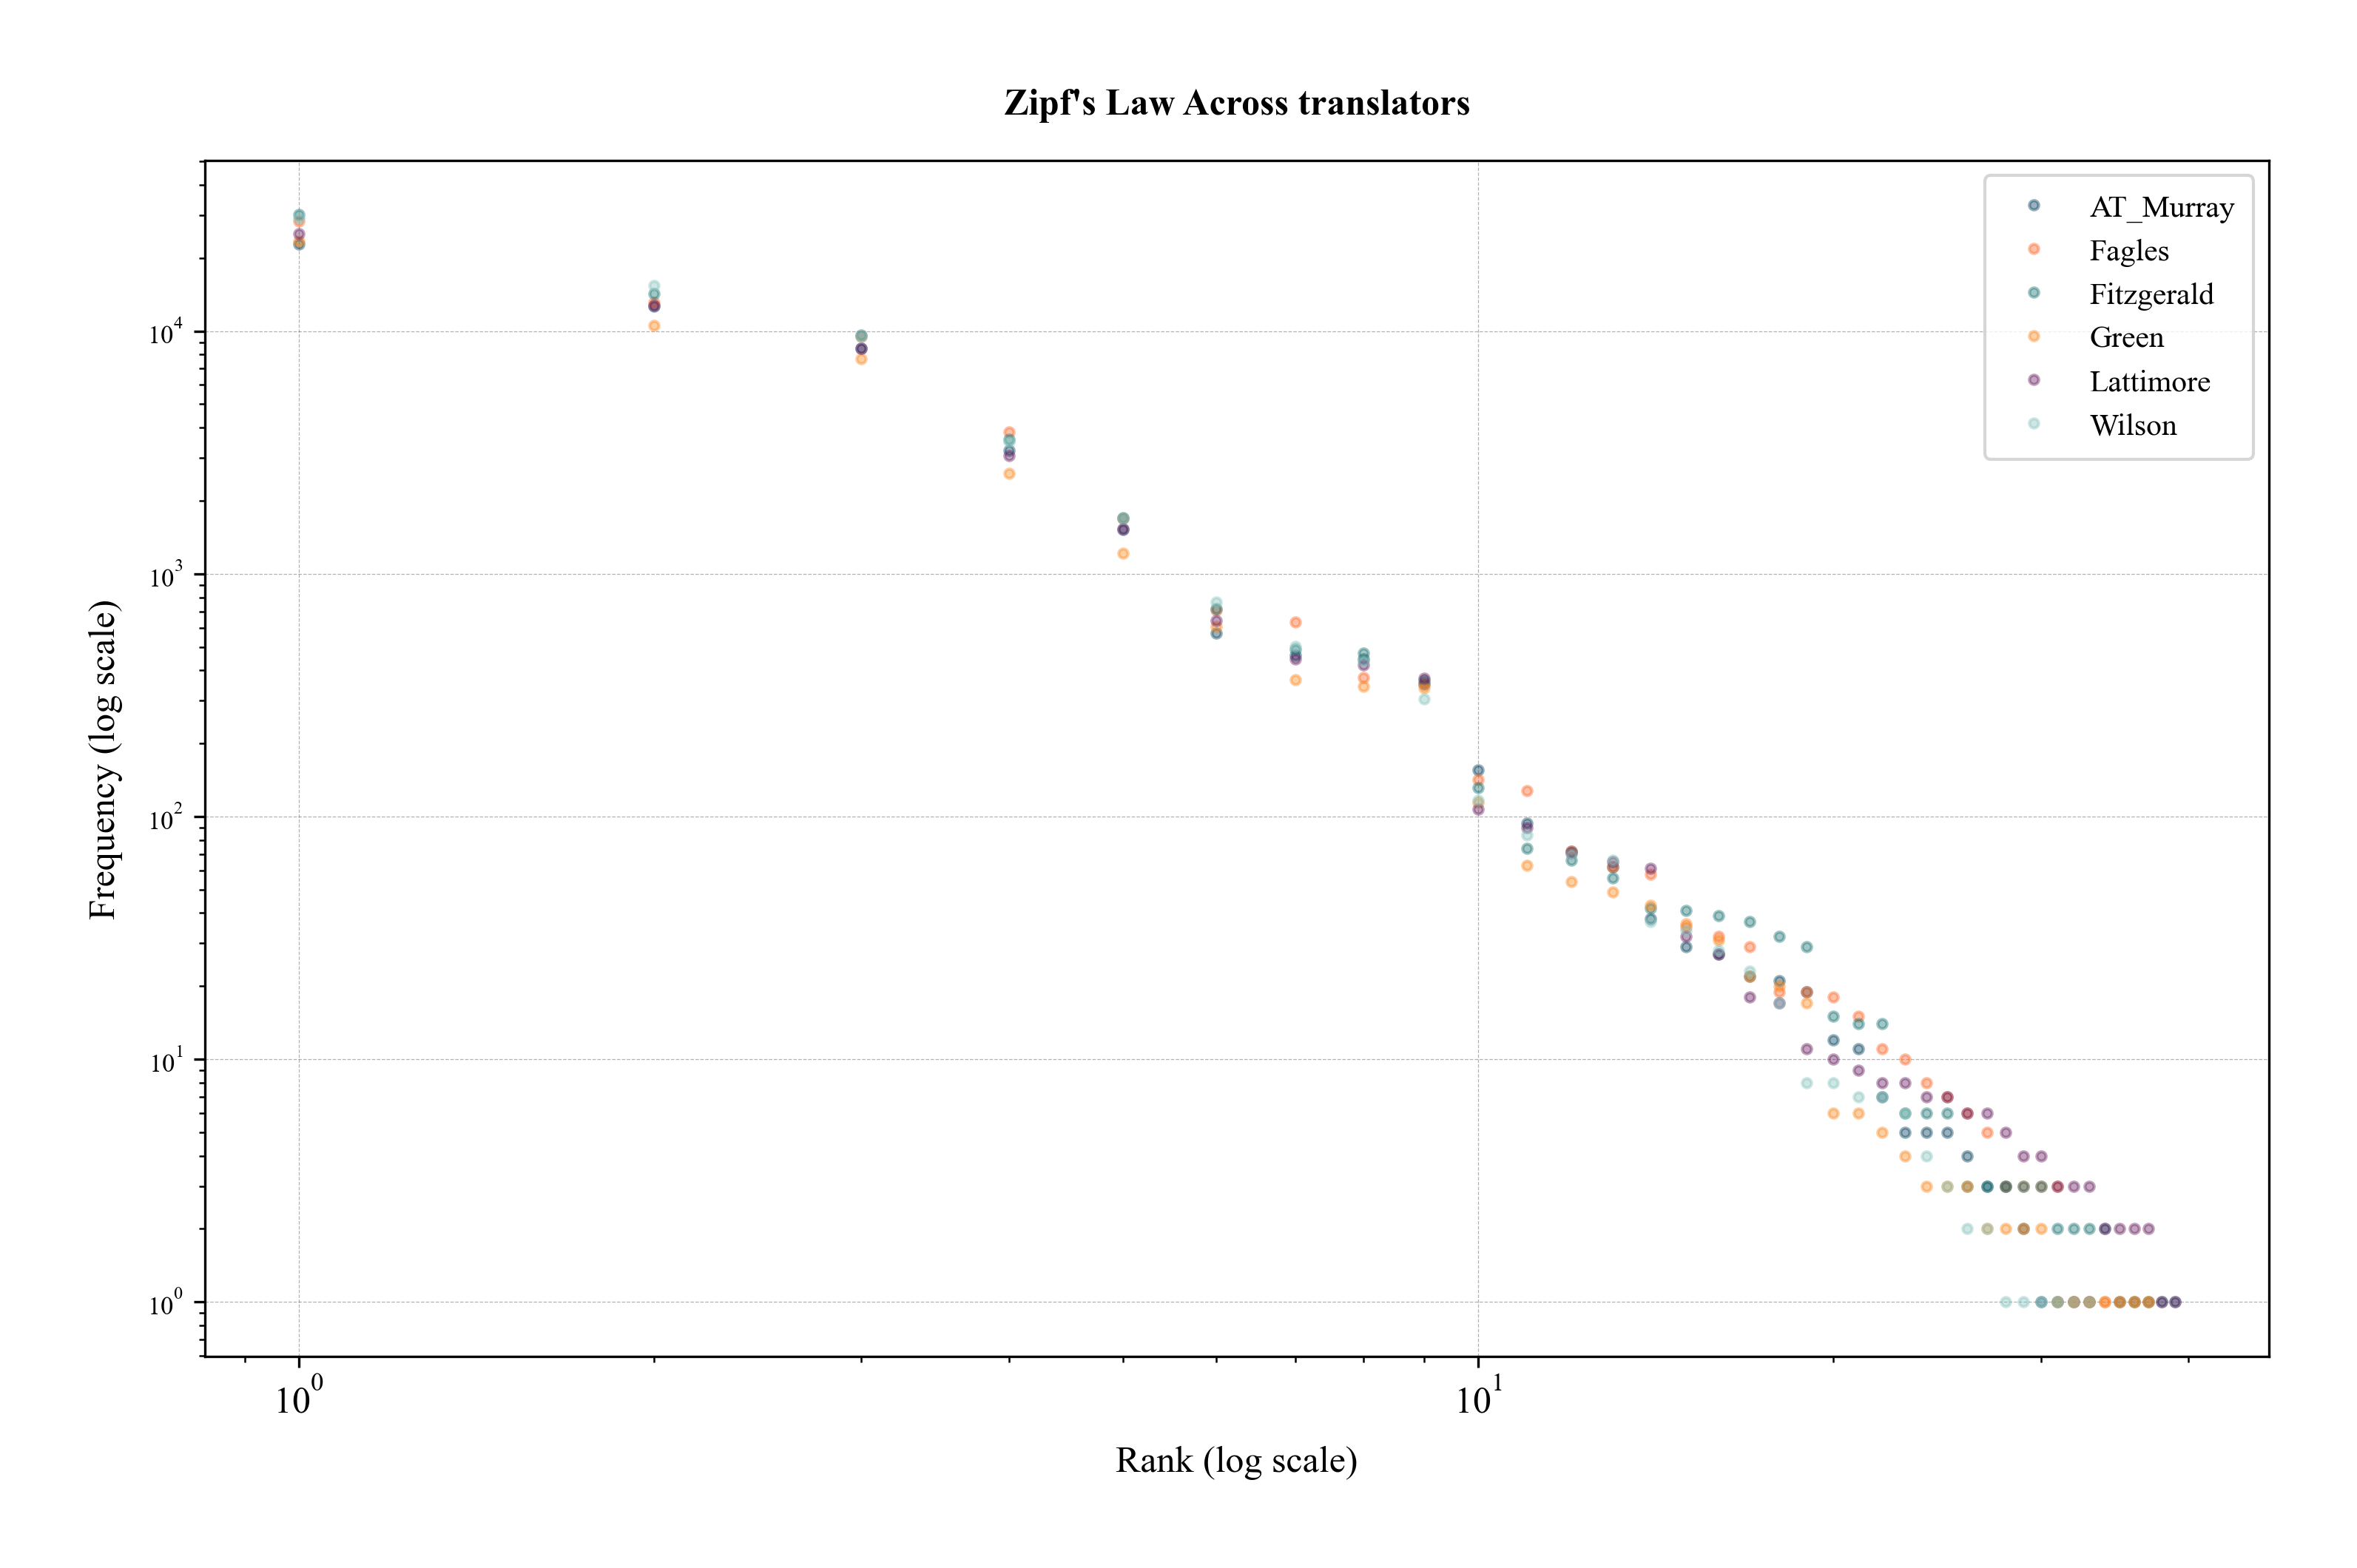

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def process_and_plot_zipfs_law(odysseys_df):
    """
    Processes the 'ety_label_counts' column to extract word frequencies,
    computes Zipf's Law distribution, and plots it.
    """
    translator_groups = odysseys_df.groupby("translator")  # Grouping by translator if an "translator" column exists
    word_freq_rank_dict = {}

    for translator, group in translator_groups:
        combined_counts = {}

        # Aggregate word frequencies across books for this translator
        for counts_dict in group["ety_label_counts"]:
            for word, count in counts_dict.items():
                combined_counts[word] = combined_counts.get(word, 0) + count

        # Convert to sorted DataFrame (descending frequency)
        df_zipf = pd.DataFrame(
            sorted(combined_counts.items(), key=lambda x: x[1], reverse=True),
            columns=["word", "frequency"]
        )
        df_zipf["rank"] = np.arange(1, len(df_zipf) + 1)
        word_freq_rank_dict[translator] = df_zipf

    # Plot the results
    for translator, df_zipf in word_freq_rank_dict.items():
        plt.loglog(df_zipf["rank"], df_zipf["frequency"], label=translator, marker=".", linestyle="None", alpha=0.4)

    plt.xlabel("Rank (log scale)")
    plt.ylabel("Frequency (log scale)")
    plt.title("Zipf's Law Across translators")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    plt.show()

# Example usage:
process_and_plot_zipfs_law(odysseys_df)

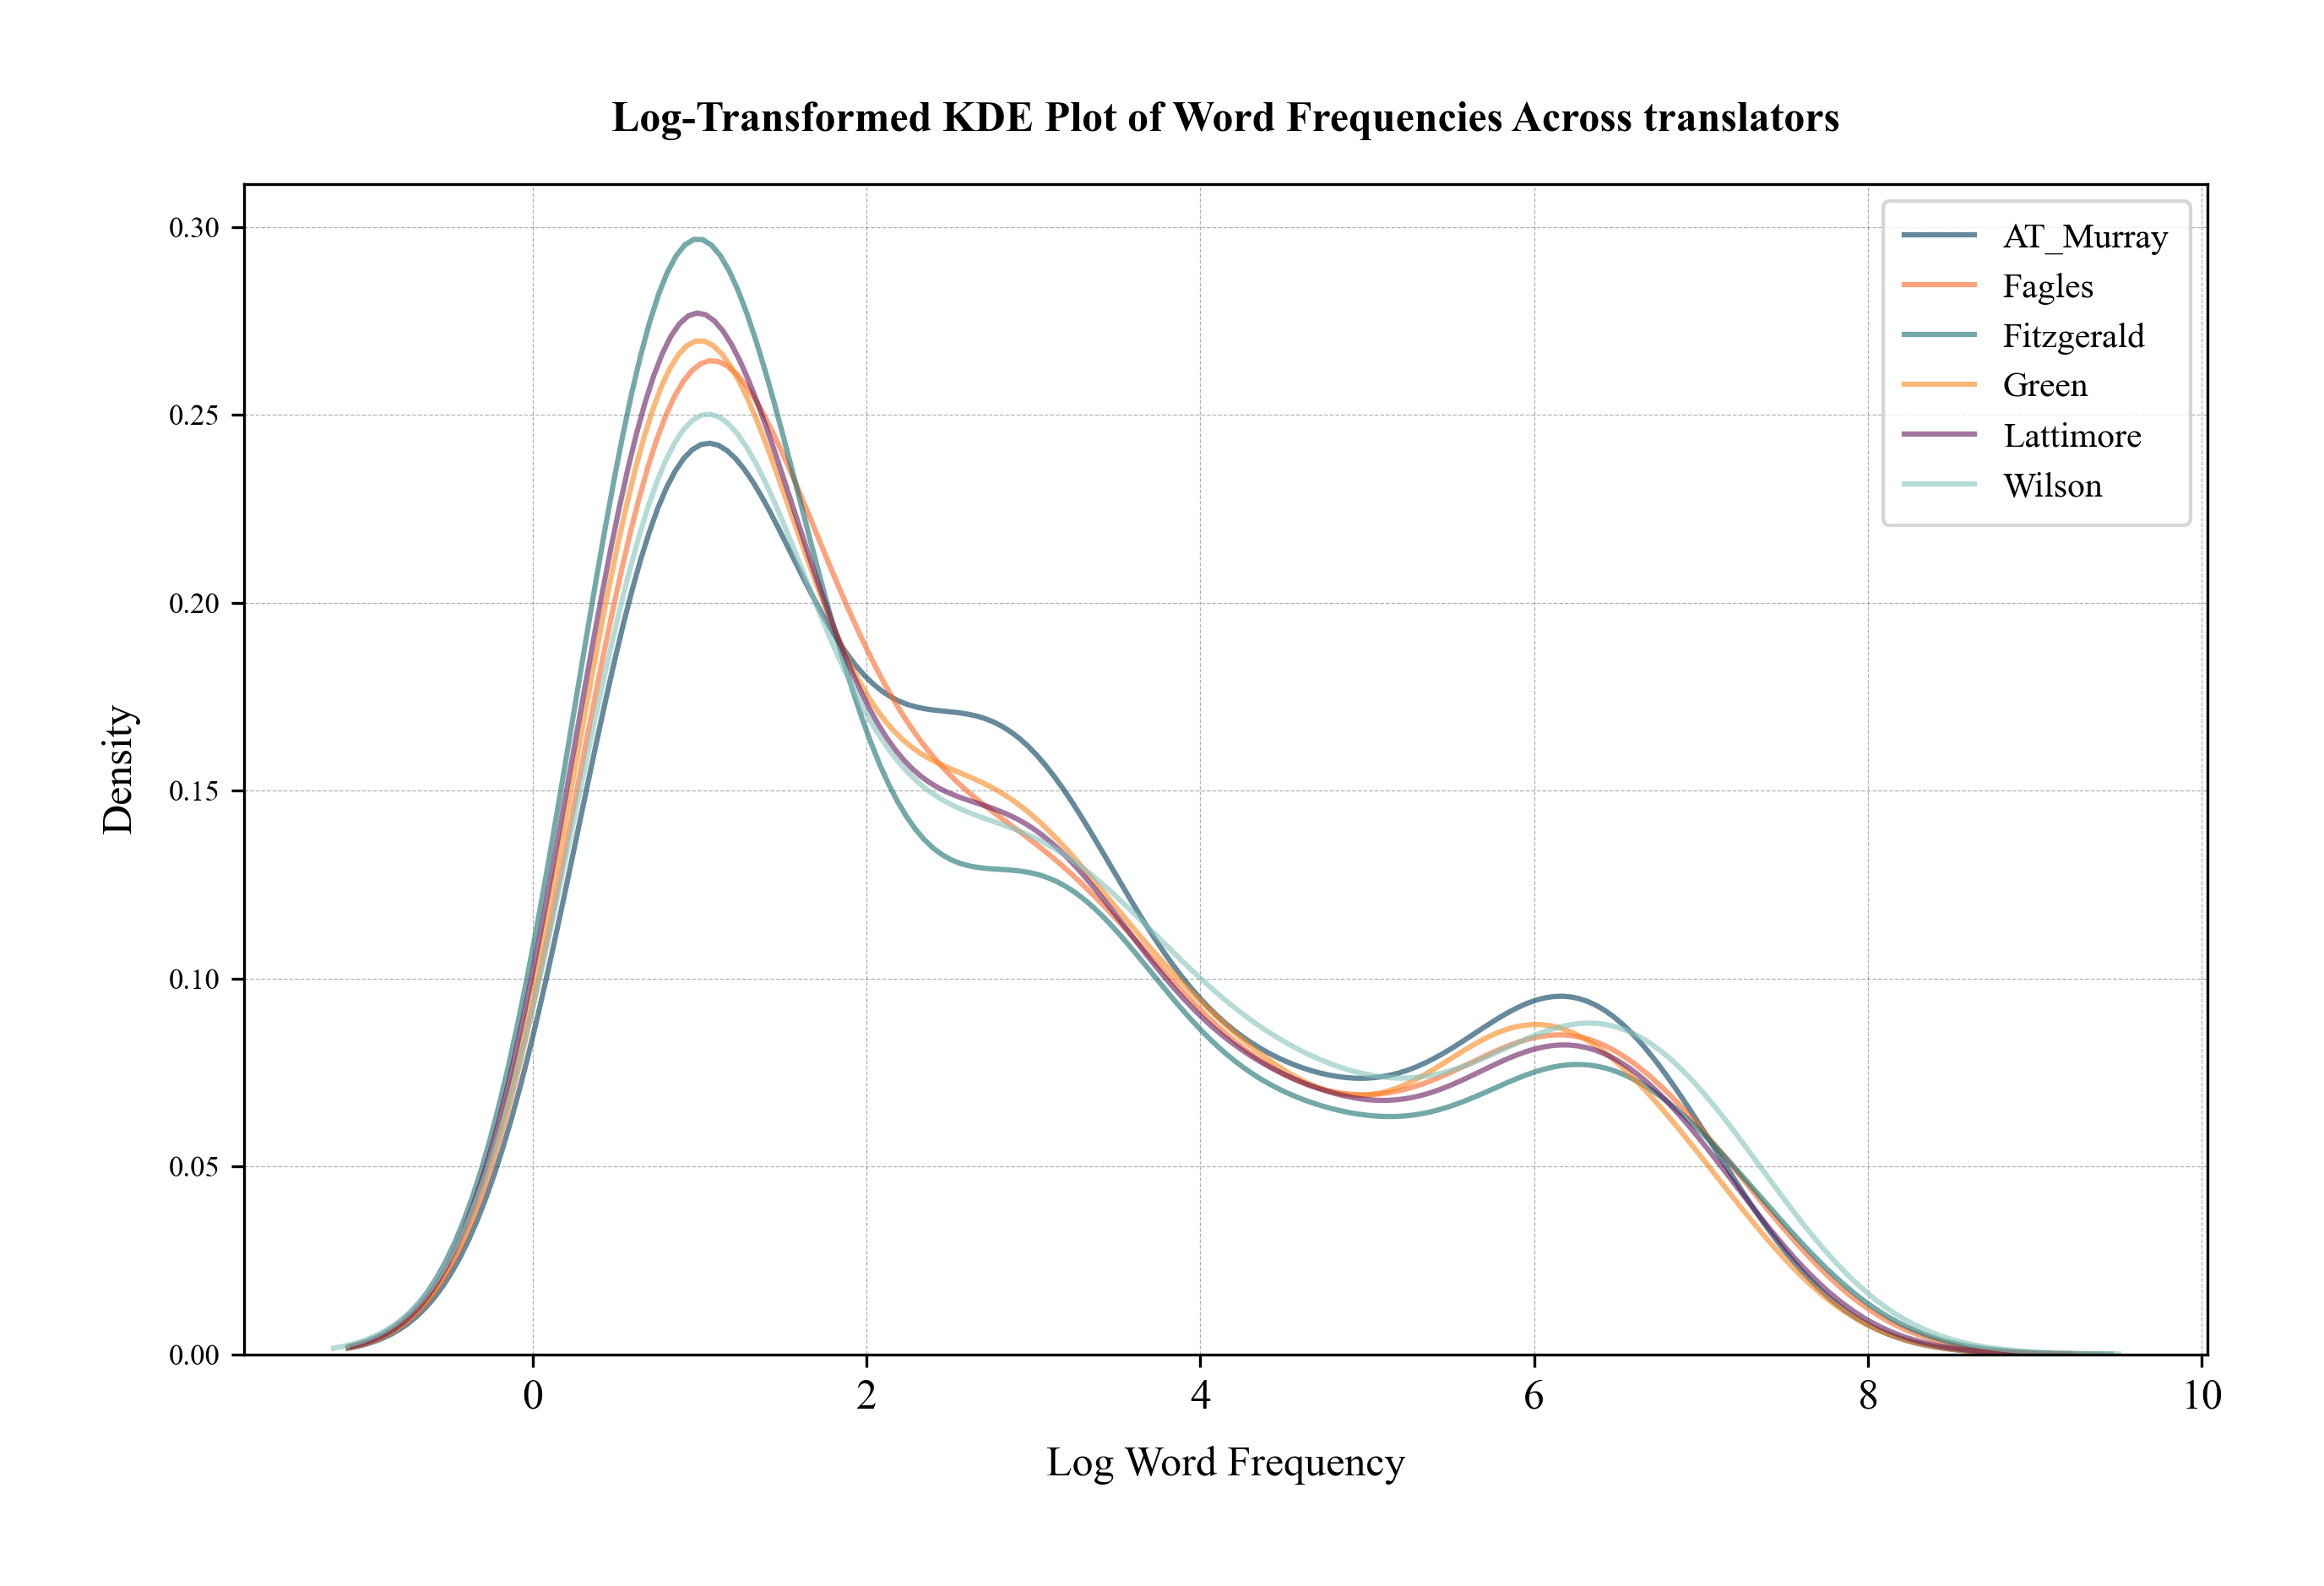

In [45]:

def plot_kde_word_frequencies(df):
    """
    Processes the 'ety_label_counts' column to extract word frequencies,
    and plots their distribution using a KDE plot.
    """
    translator_groups = df.groupby("translator")  # Grouping by translator
    plt.figure(figsize=(10, 6))

    for translator, group in translator_groups:
        all_frequencies = []

        # Aggregate word frequencies across books for this translator
        for counts_dict in group["ety_label_counts"]:
            all_frequencies.extend(counts_dict.values())  # Collect all word frequencies

        # Plot KDE if there are enough points
        if len(all_frequencies) > 1:
            sns.kdeplot(all_frequencies, label=translator, fill=True, alpha=0.4)

    plt.xlabel("Word Frequency")
    plt.ylabel("Density")
    plt.title("KDE Plot of Word Frequencies Across translators")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    plt.show()


def plot_log_kde_word_frequencies(df):
    translator_groups = df.groupby("translator")
    plt.figure(figsize=(10, 6))

    for translator, group in translator_groups:
        all_frequencies = []

        for counts_dict in group["ety_label_counts"]:
            all_frequencies.extend(counts_dict.values())

        # Log-transform (avoid log(0) errors)
        log_frequencies = np.log1p(all_frequencies)  # log(1 + x) to handle zero values safely

        if len(log_frequencies) > 1:
            sns.kdeplot(log_frequencies, label=translator, fill=False, alpha=0.6)

    plt.xlabel("Log Word Frequency")
    plt.ylabel("Density")
    plt.title("Log-Transformed KDE Plot of Word Frequencies Across translators")
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.3, alpha=0.3)
    plt.show()
# Example usage:
plot_log_kde_word_frequencies(odysseys_df)

## Comparing Translations's Etymology Distribution

In [6]:
def expand_ety_label_counts(df, column='ety_label_counts'):
    # Convert list of dictionaries into a DataFrame
    ety_df = df[column].apply(pd.Series).fillna(0).astype(int)
    
    # Concatenate with original df to keep 'translator' and 'book_num'
    df_ety_freq = pd.concat([df[['translator', 'book_num']], ety_df], axis=1)
    
    return df_ety_freq

df_ety_freq = expand_ety_label_counts(odysseys_df)

df_ety_freq.head(3)

,translator,book_num,ang,grc,eng,enm,fro,lat,xno,non,...,tnq,frk,odt,nld,gla,pro,jpn,fas,afr,enn
0,AT_Murray,1,459,12,804,294,45,113,20,25,...,0,0,0,0,0,0,0,0,0,0
1,AT_Murray,2,494,15,771,285,49,125,35,11,...,0,0,0,0,0,0,0,0,0,0
2,AT_Murray,3,503,16,1032,334,59,131,20,16,...,0,0,0,0,0,0,0,0,0,0


In [46]:
e.check_df(df_ety_freq)

Mr righteous here has no missing values!

* df columns: Index(['translator',   'book_num',        'ang',        'grc',        'eng',
              'enm',        'fro',        'lat',        'xno',        'non',
              'heb',        'fra',        'p_g',        'ita',        'tur',
              'msa',        'gml',        'spa',          nan,        'frm',
              'fin',        'por',        'dum',        'ara',        'peo',
              'arg',        'sux',        'sga',        'cym',        'deu',
              'san',        'sco',        'gmh',        'hin',        'goh',
              'arw',        'rus',        'tnq',        'frk',        'odt',
              'nld',        'gla',        'pro',        'jpn',        'fas',
              'afr',        'enn'],
      dtype='object') 

* Shape: (144, 47) 

* Total memory in MB: 0.053827


### **Origins across books: Fitzgerald and Wilson**

These plots show no significant difference between Fitzgerald and Wilson. This trend is visible acroos all authors. 

<Figure size 3600x2100 with 0 Axes>

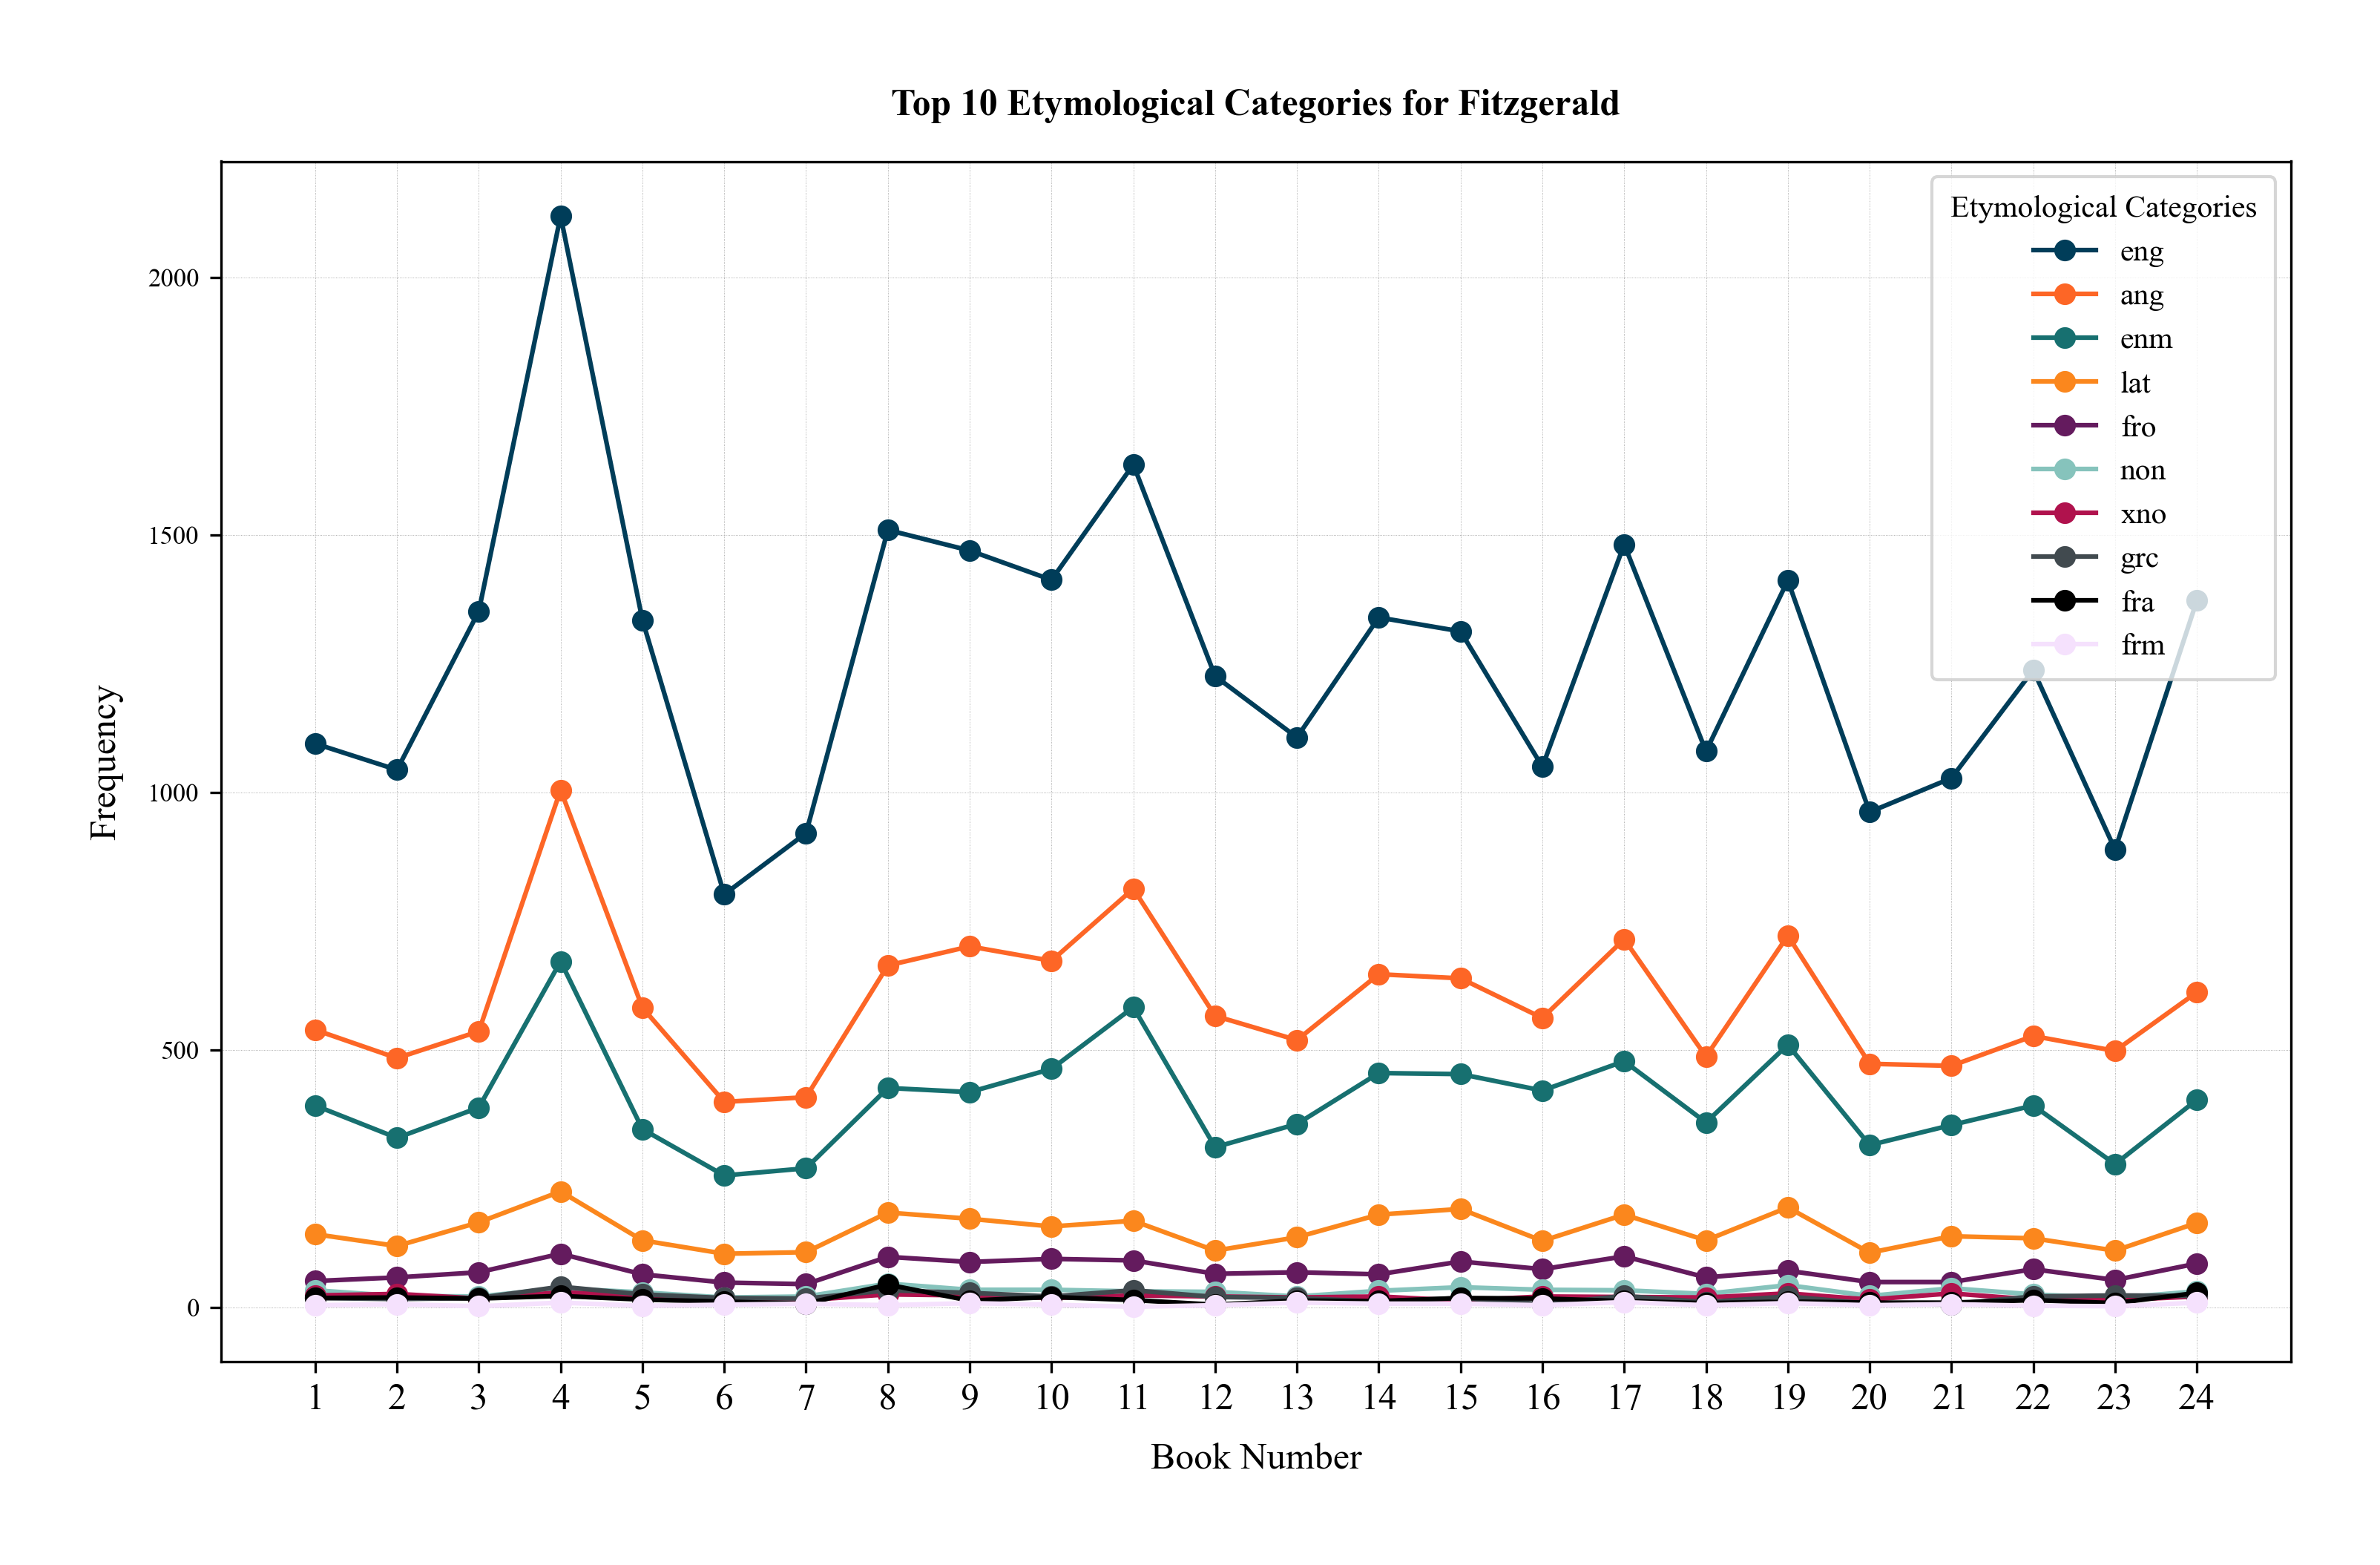

<Figure size 3600x2100 with 0 Axes>

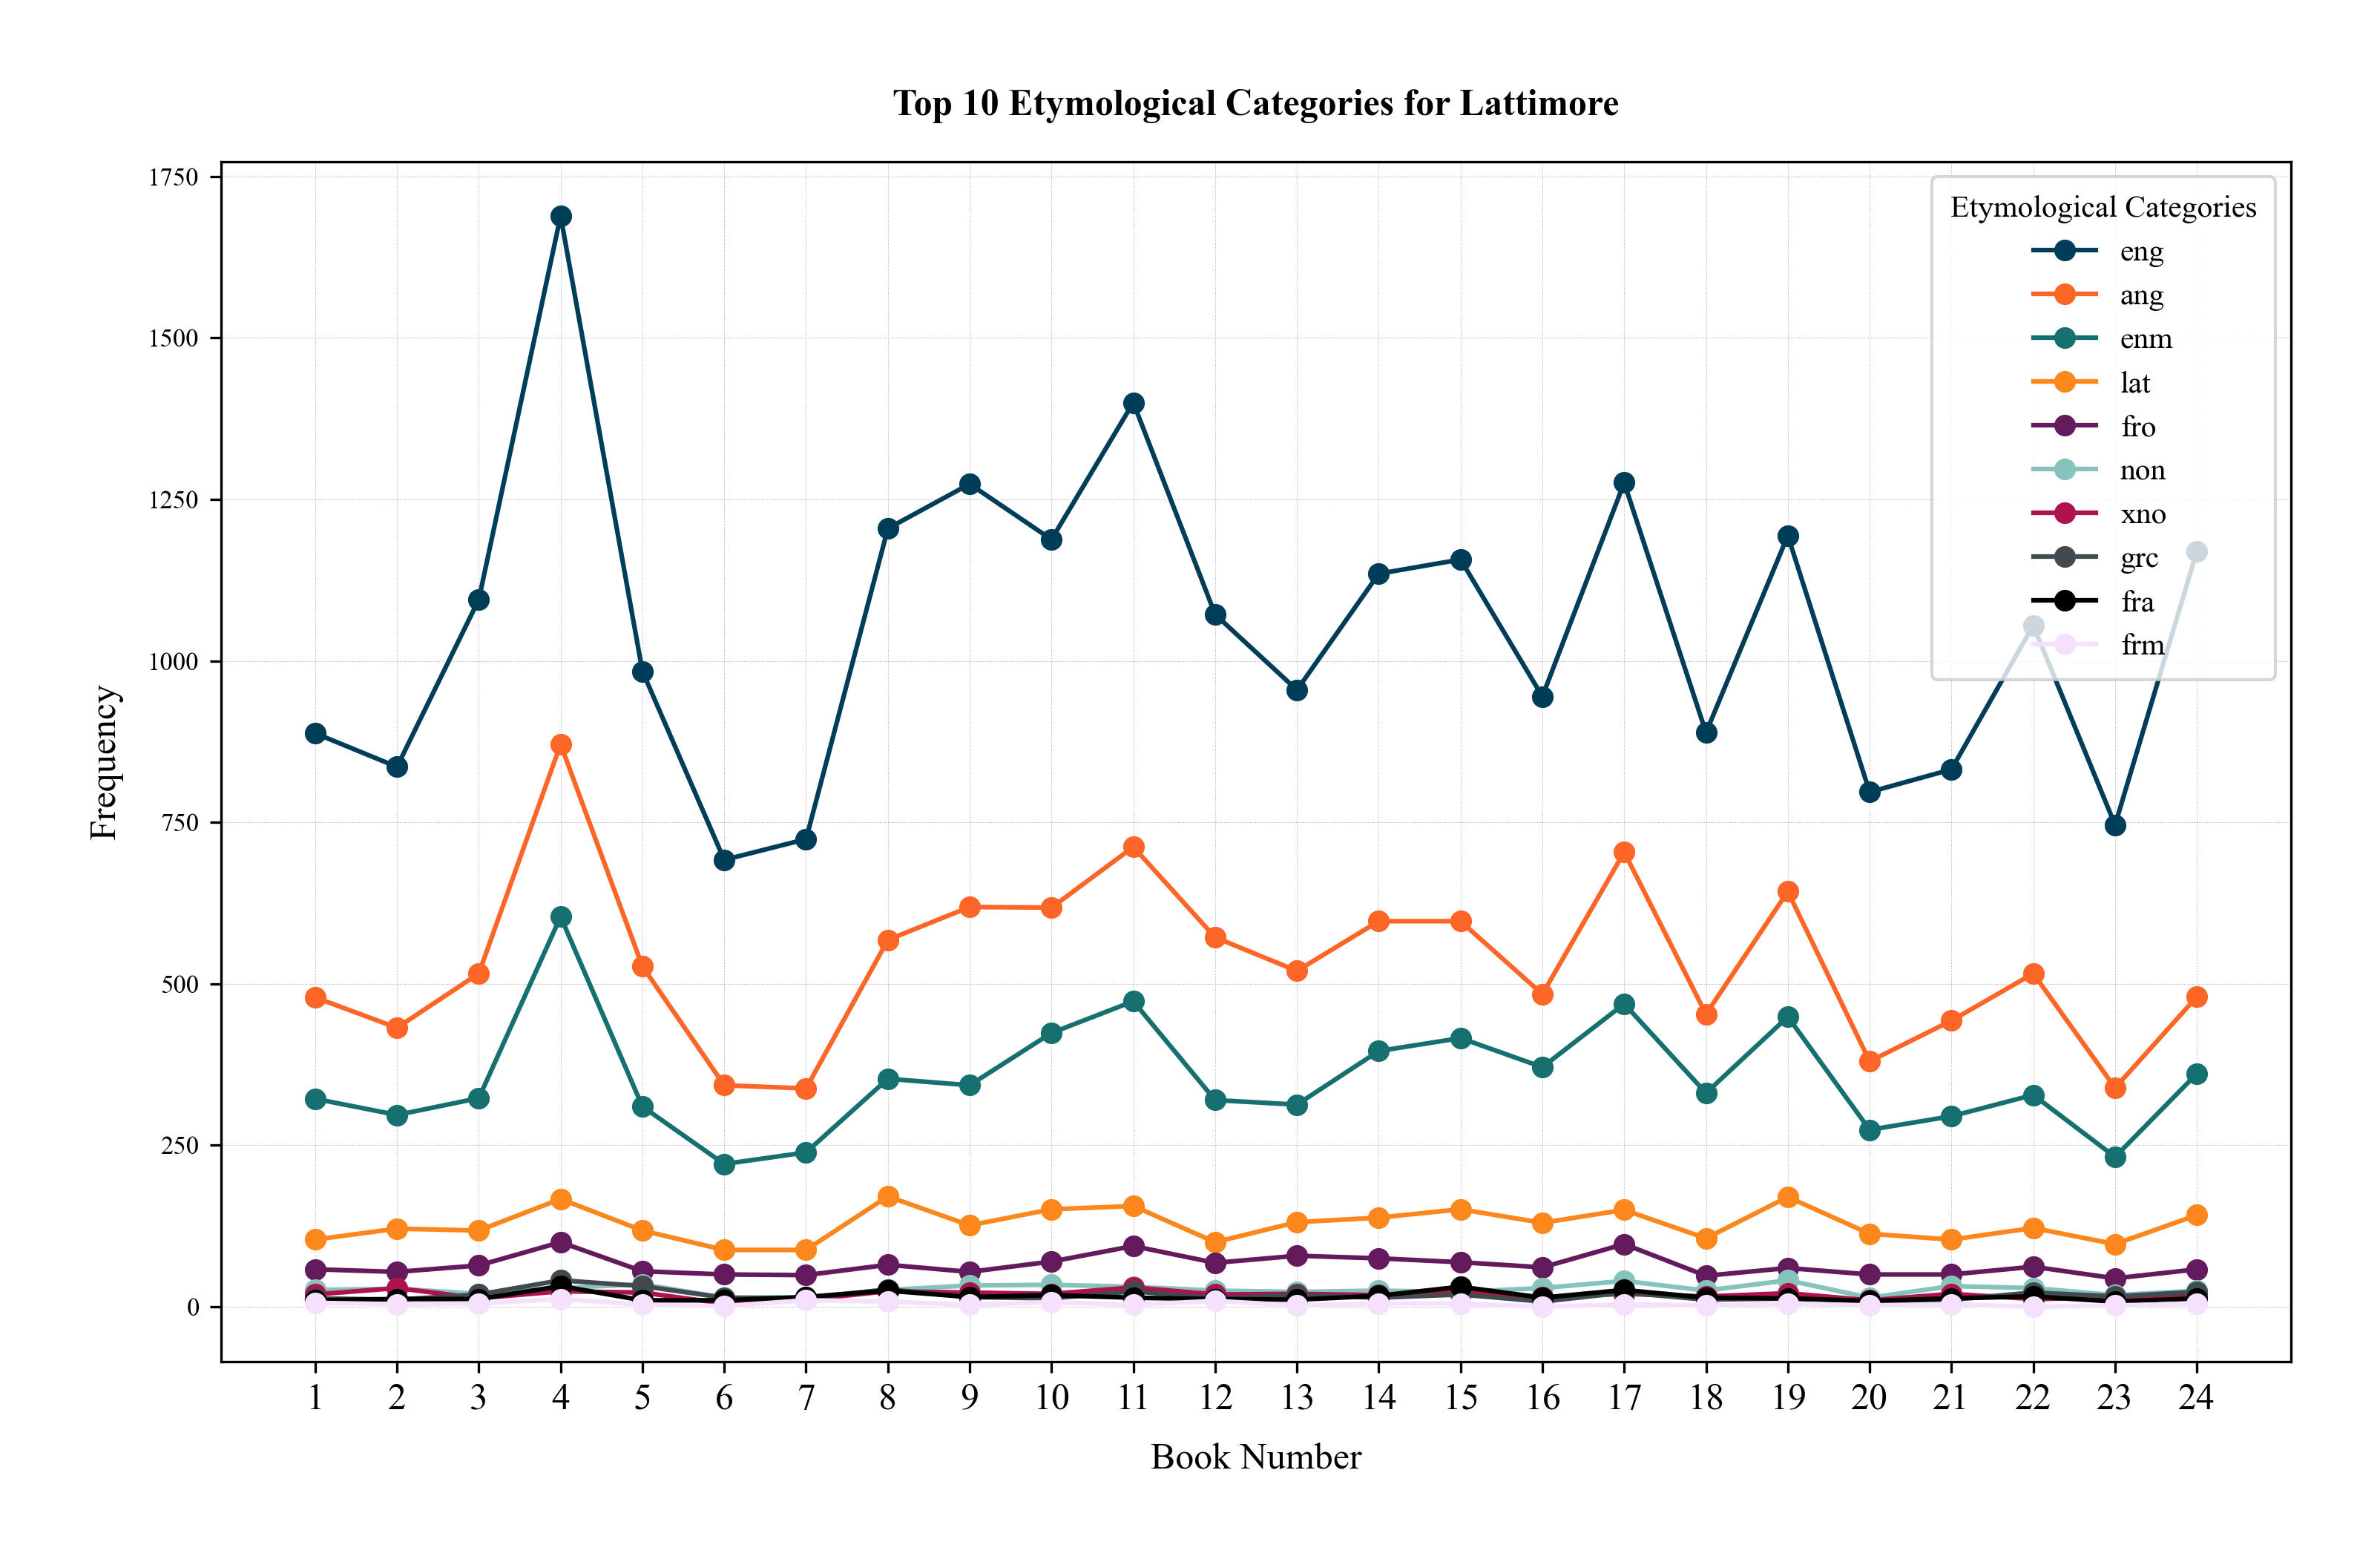

In [ ]:
# Origins across books: Fitzgerald and Wilson
# Plotting Frequencies
def plot_ety_freq(df, translator=None, top_n=10):
    """
    Plot the frequencies of etymological categories for a given translator."
    """

    df = df_ety_freq[df_ety_freq['translator'] == translator]

    # Sum frequencies for each category and get the top n
    top_10_categories = df.drop(columns=['translator', 'book_num'])\
                          .sum().nlargest(top_n).index

    # Plot the top n categories over book_num
    plt.figure(figsize=(12, 7))
    df.set_index('book_num')[top_10_categories].plot(kind='line', 
                                                     figsize=(12, 7), marker='o')
    plt.title(f"Top {top_n} Etymological Categories for {translator}")
    plt.xlabel("Book Number")
    plt.ylabel("Frequency")
    plt.xticks(ticks=range(1, 25), labels=range(1, 25))
    plt.grid(alpha=0.4)
    plt.legend(title="Etymological Categories")
    plt.grid(True)
    plt.show()

# Example usage
plot_ety_freq(df_ety_freq, translator='Fitzgerald', top_n=10)
plot_ety_freq(df_ety_freq, translator='Lattimore', top_n=10)

<Figure size 3600x2100 with 0 Axes>

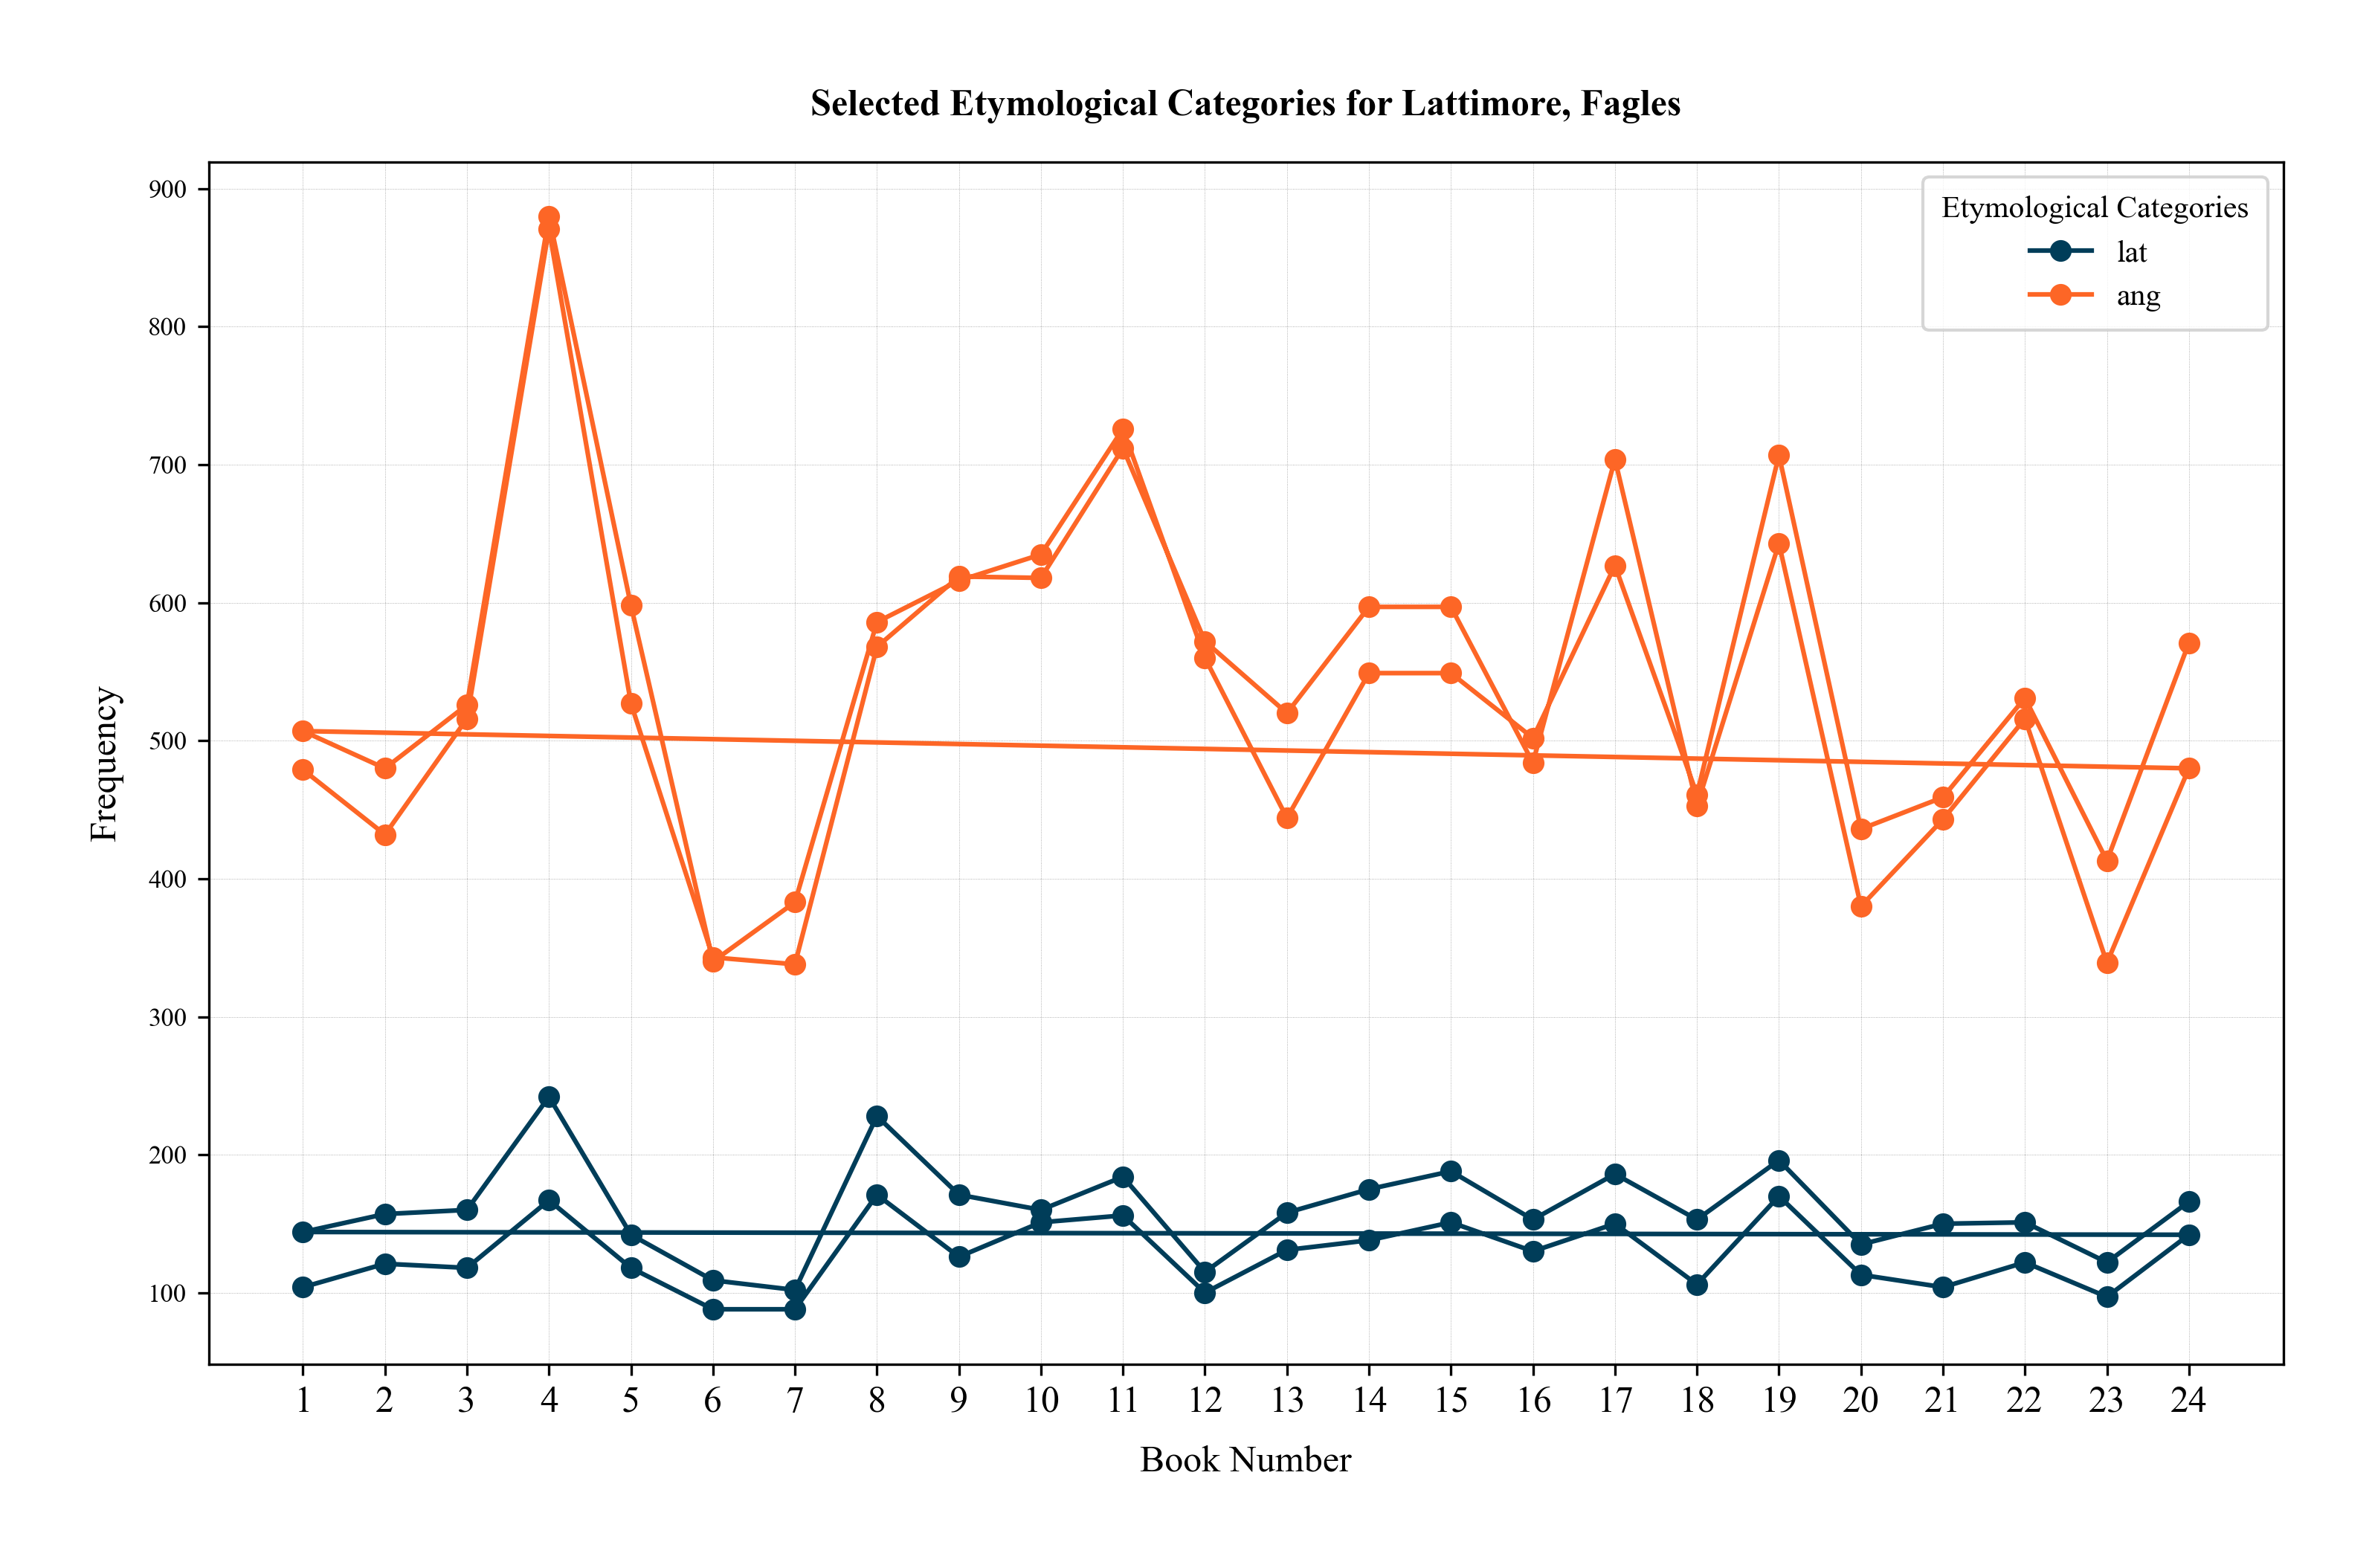

In [48]:
# Focusing on freq for specified etymological categories
# Latin vs Anglo-Saxon seems like an interesting match

def plot_ety_cat(df, cat=['lat', 'ang'], translator=['all'], top_n=None):
    """
    Plot the frequencies of selected etymological categories across books for given translators.
    
    Parameters:
    - df: DataFrame containing etymological frequency data.
    - cat: List of categories to plot (default: ['lat', 'ang']).
    - translator: List of translators to filter (default: ['all'] for all translators).
    - top_n: Optional, to dynamically select the top N most frequent categories.
    """

    if 'all' not in translator:
        df = df[df['translator'].isin(translator)]  # Filter by selected translators

    # Sum frequencies for each category and get the top_n if specified
    if top_n:
        selected_cats = df.drop(columns=['translator', 'book_num']).sum().nlargest(top_n).index.tolist()
    else:
        selected_cats = [c for c in cat if c in df.columns]  # Ensure selected categories exist in DataFrame

    # Plot the categories over book_num
    plt.figure(figsize=(12, 7))
    df.set_index('book_num')[selected_cats].plot(kind='line', marker='o', figsize=(12, 7))

    plt.title(f"Selected Etymological Categories for {', '.join(translator) if 'all' not in translator else 'All Translators'}")
    plt.xlabel("Book Number")
    plt.ylabel("Frequency")
    plt.xticks(ticks=range(1, 25), labels=range(1, 25))
    plt.legend(title="Etymological Categories")
    plt.grid(alpha=0.4)
    plt.show()

# Example usage:
# plot_ety_cat(df_ety_freq, cat=['lat', 'ang'], translator=['Lattimore', 'Fagles'])
plot_ety_cat(df_ety_freq, cat=['lat', 'ang'], translator=['Lattimore', 'Fagles'])

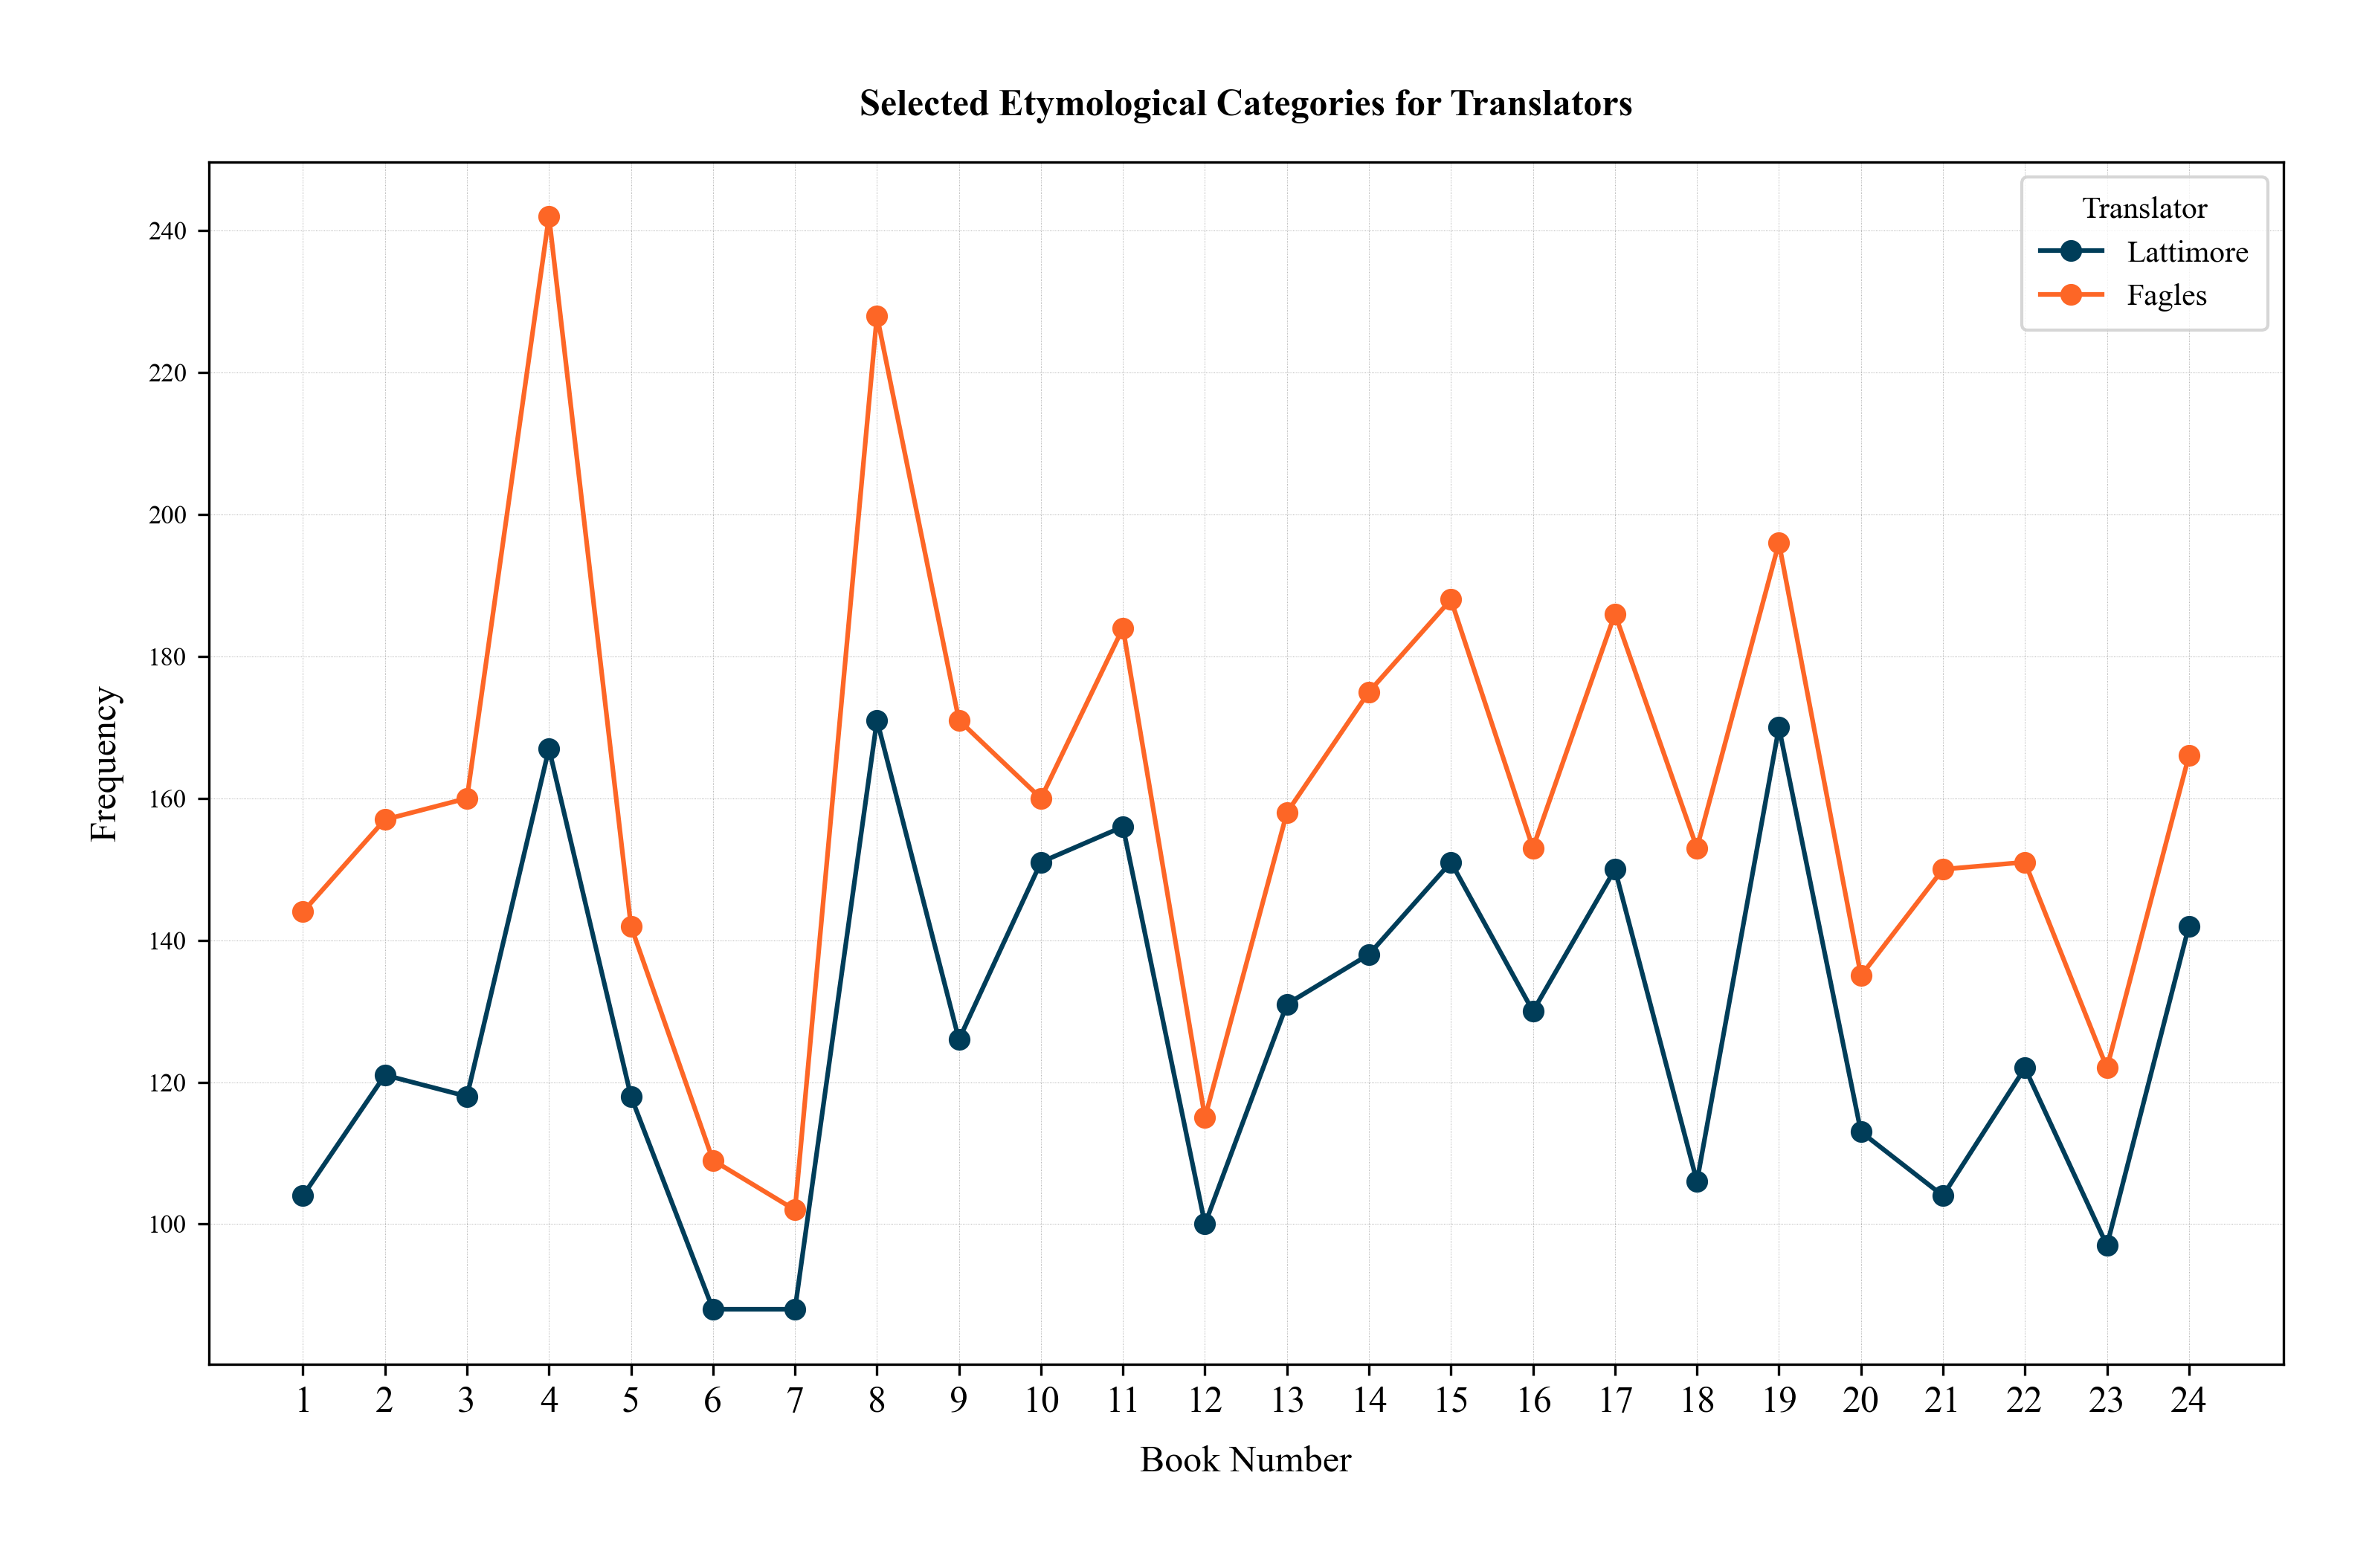

In [50]:
import matplotlib.pyplot as plt

def plot_ety_cat(df, cat=['lat', 'ang'], translator=['all'], top_n=None):
    """
    Plot the frequencies of selected etymological categories across books for given translators.
    
    Parameters:
    - df: DataFrame containing etymological frequency data.
    - cat: List of categories to plot (default: ['lat', 'ang']).
    - translator: List of translators to filter (default: ['all'] for all translators).
    - top_n: Optional, to dynamically select the top N most frequent categories.
    """

    if 'all' not in translator:
        df = df[df['translator'].isin(translator)]  # Filter by selected translators

    # Select categories
    if top_n:
        selected_cats = df.drop(columns=['translator', 'book_num']).sum().nlargest(top_n).index.tolist()
    else:
        selected_cats = [c for c in cat if c in df.columns]  # Ensure selected categories exist in DataFrame

    plt.figure(figsize=(12, 7))

    # Loop over each translator to plot separately
    for trans in df['translator'].unique():
        df_trans = df[df['translator'] == trans]  # Filter by translator
        df_trans.set_index('book_num')[selected_cats].sum(axis=1).plot(
            marker='o', label=trans  # Legend will now show translators
        )

    plt.title(f"Selected Etymological Categories for Translators")
    plt.xlabel("Book Number")
    plt.ylabel("Frequency")
    plt.xticks(ticks=range(1, 25), labels=range(1, 25))
    plt.legend(title="Translator")  # Legend now shows translators
    plt.grid(alpha=0.4)
    plt.show()

# Example usage:
plot_ety_cat(df_ety_freq, cat=['lat'], translator=['Lattimore', 'Fagles'])
# plot_ety_cat(df_ety_freq, cat=['lat', 'ang', 'cym'], translator=['all'])

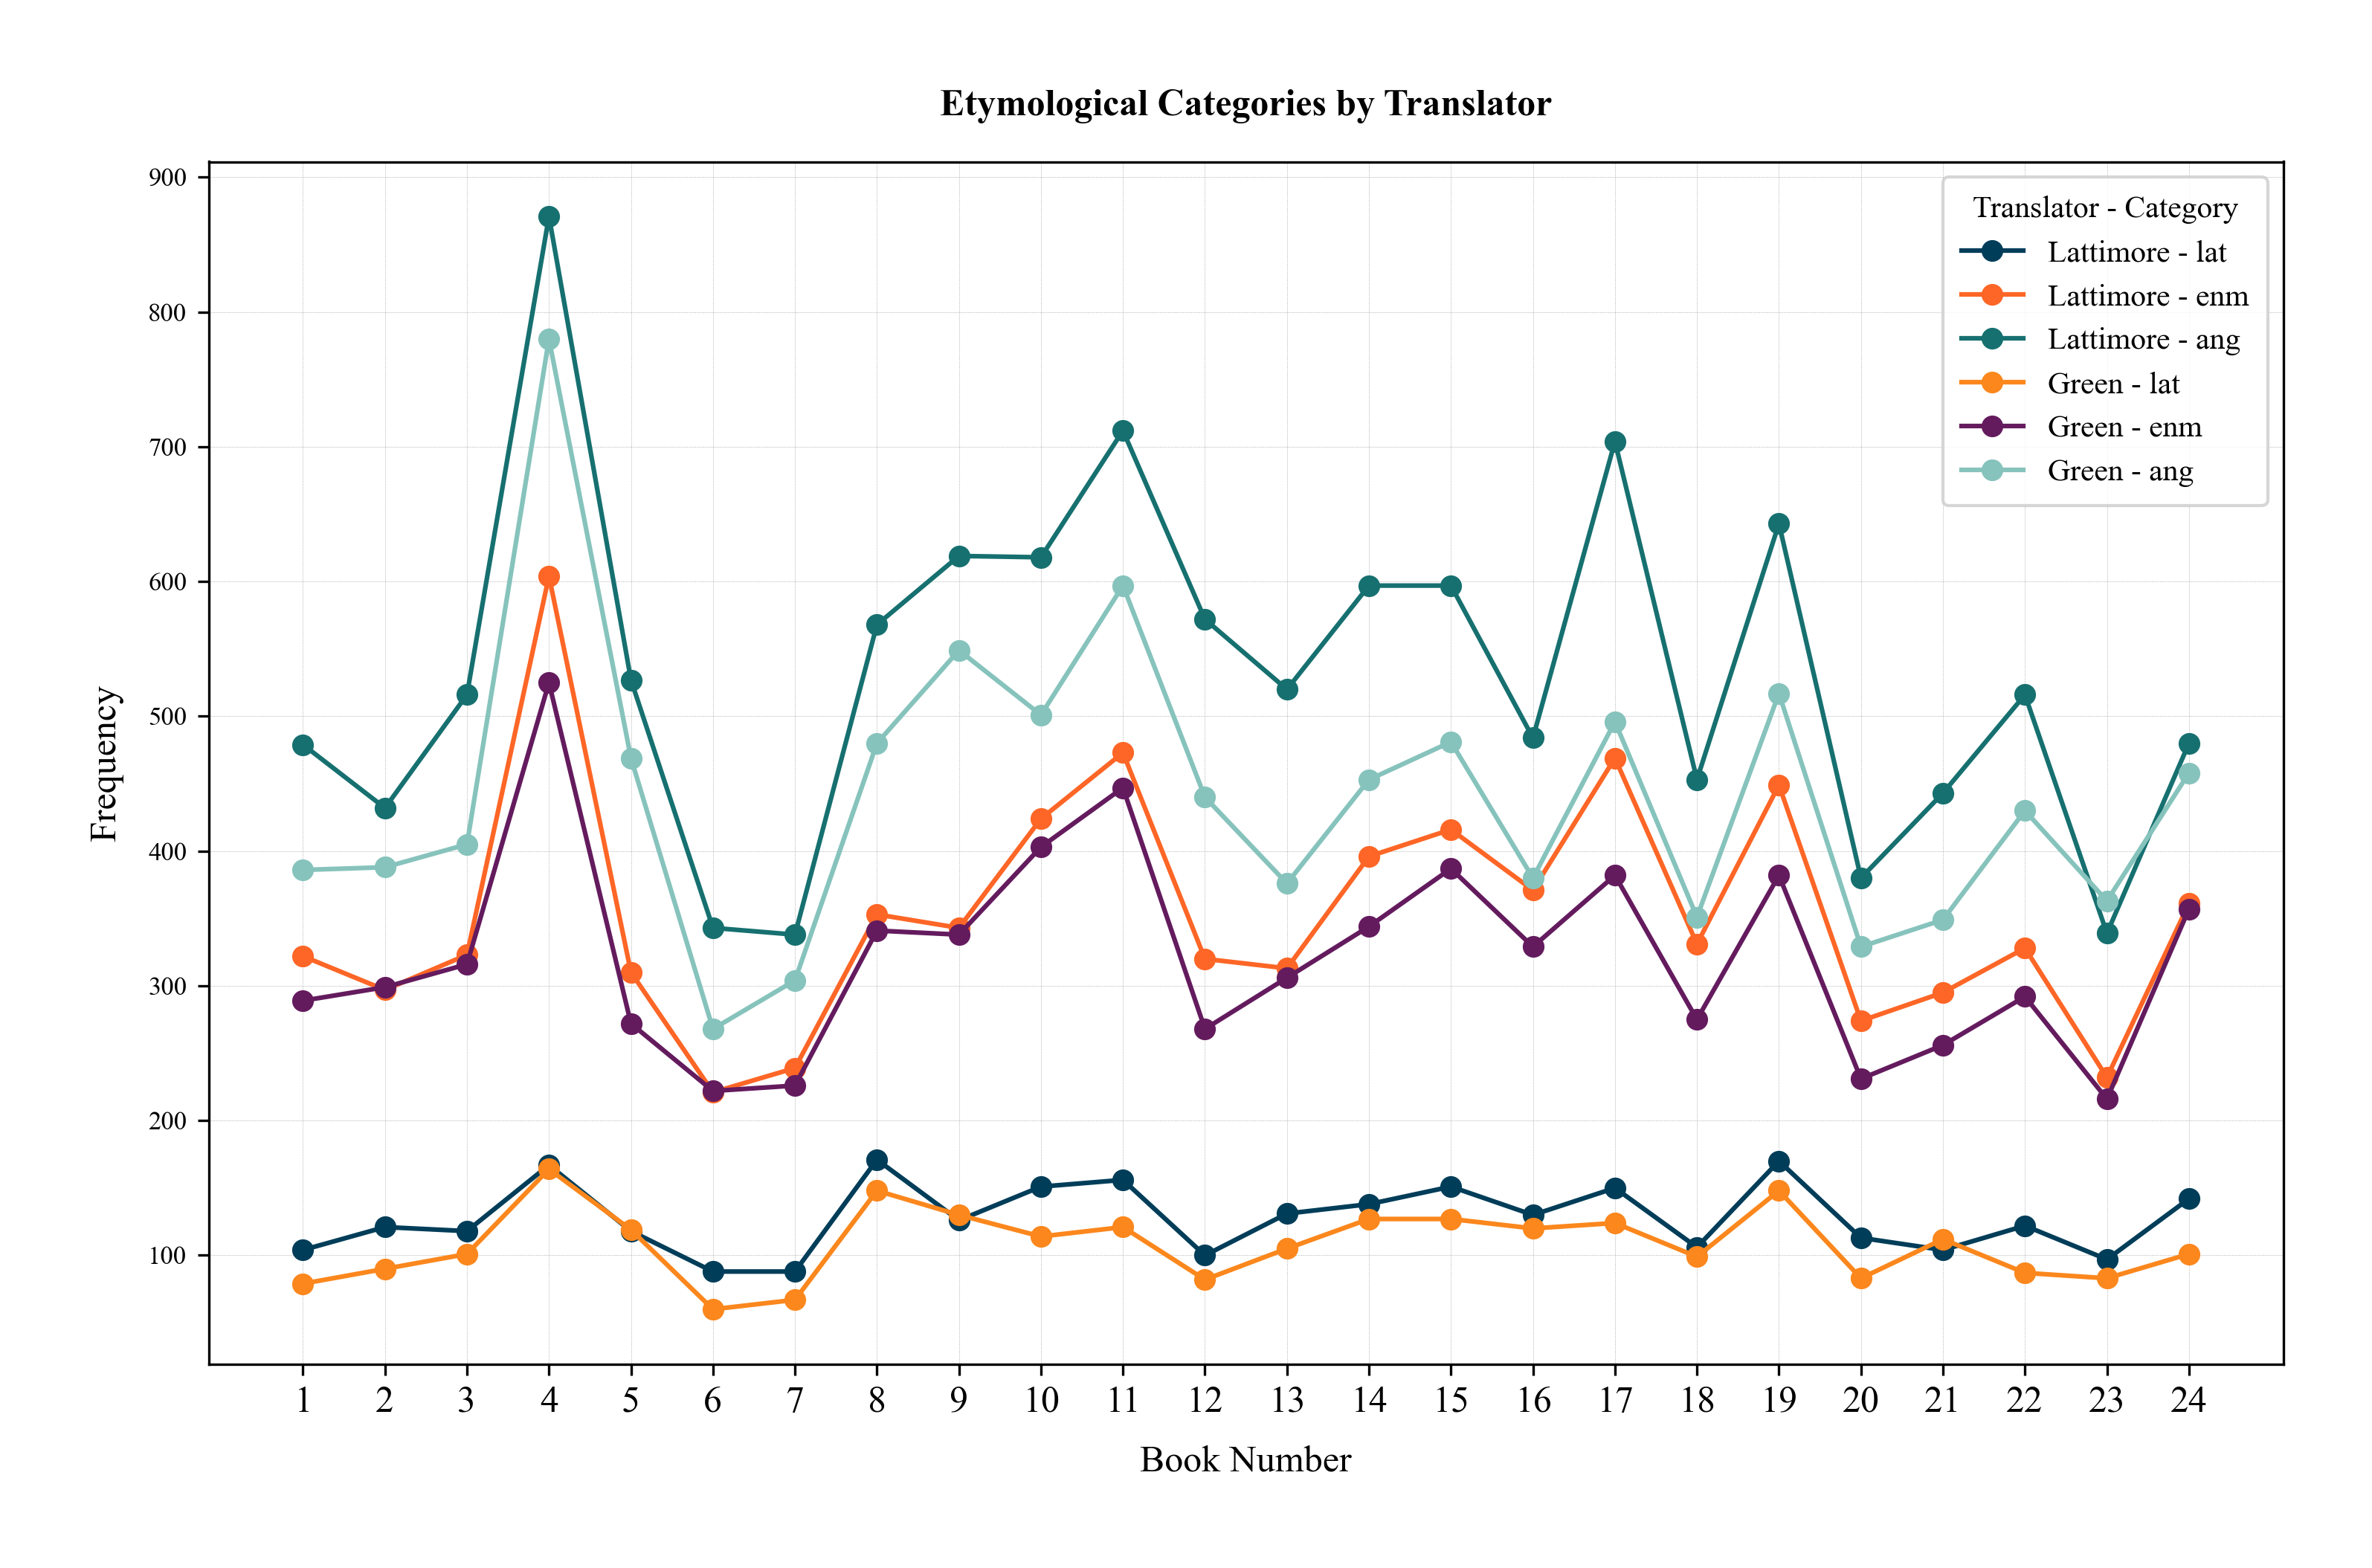

In [57]:
import matplotlib.pyplot as plt

def plot_ety_cat(df, cat=['lat', 'ang', 'enm'], translator=['all']):
    """
    Plot the frequencies of selected etymological categories across books for given translators.
    
    Parameters:
    - df: DataFrame containing etymological frequency data.
    - cat: List of categories to plot (default: ['lat', 'ang']).
    - translator: List of translators to filter (default: ['all'] for all translators).
    """

    if 'all' not in translator:
        df = df[df['translator'].isin(translator)]  # Filter by selected translators

    plt.figure(figsize=(12, 7))

    # Loop over each translator and each category separately
    for trans in df['translator'].unique():
        df_trans = df[df['translator'] == trans]  # Filter for translator

        for category in cat:
            if category in df.columns:  # Ensure the category exists
                plt.plot(
                    df_trans['book_num'], df_trans[category], 
                    marker='o', linestyle='-', label=f"{trans} - {category}"
                )

    plt.title("Etymological Categories by Translator")
    plt.xlabel("Book Number")
    plt.ylabel("Frequency")
    plt.xticks(ticks=range(1, 25), labels=range(1, 25))
    plt.legend(title="Translator - Category")  # Now legend shows both
    plt.grid(alpha=0.4)
    plt.show()

# Example usage:
plot_ety_cat(df_ety_freq, cat=['lat', 'enm', 'ang'], translator=['Lattimore', 'Green'])

In [10]:
# # Single book analysis
# oz.plot_etymology_counts(my_df, "Murray", book_range=1)

# # Multiple books
# oz.plot_etymology_counts(my_df, "Murray", book_range=[1, 5, 9])

# # Range of books
# oz.plot_etymology_counts(my_df, "Butler", book_range=(1, 5))

# # Compare translators
# oz.plot_etymology_comparison(my_df, ["Murray", "Butler", "Pope"], book_num=1)

# # Create heatmap visualization
# oz.plot_etymology_heatmap(my_df, "Murray", book_range=(1, 24))

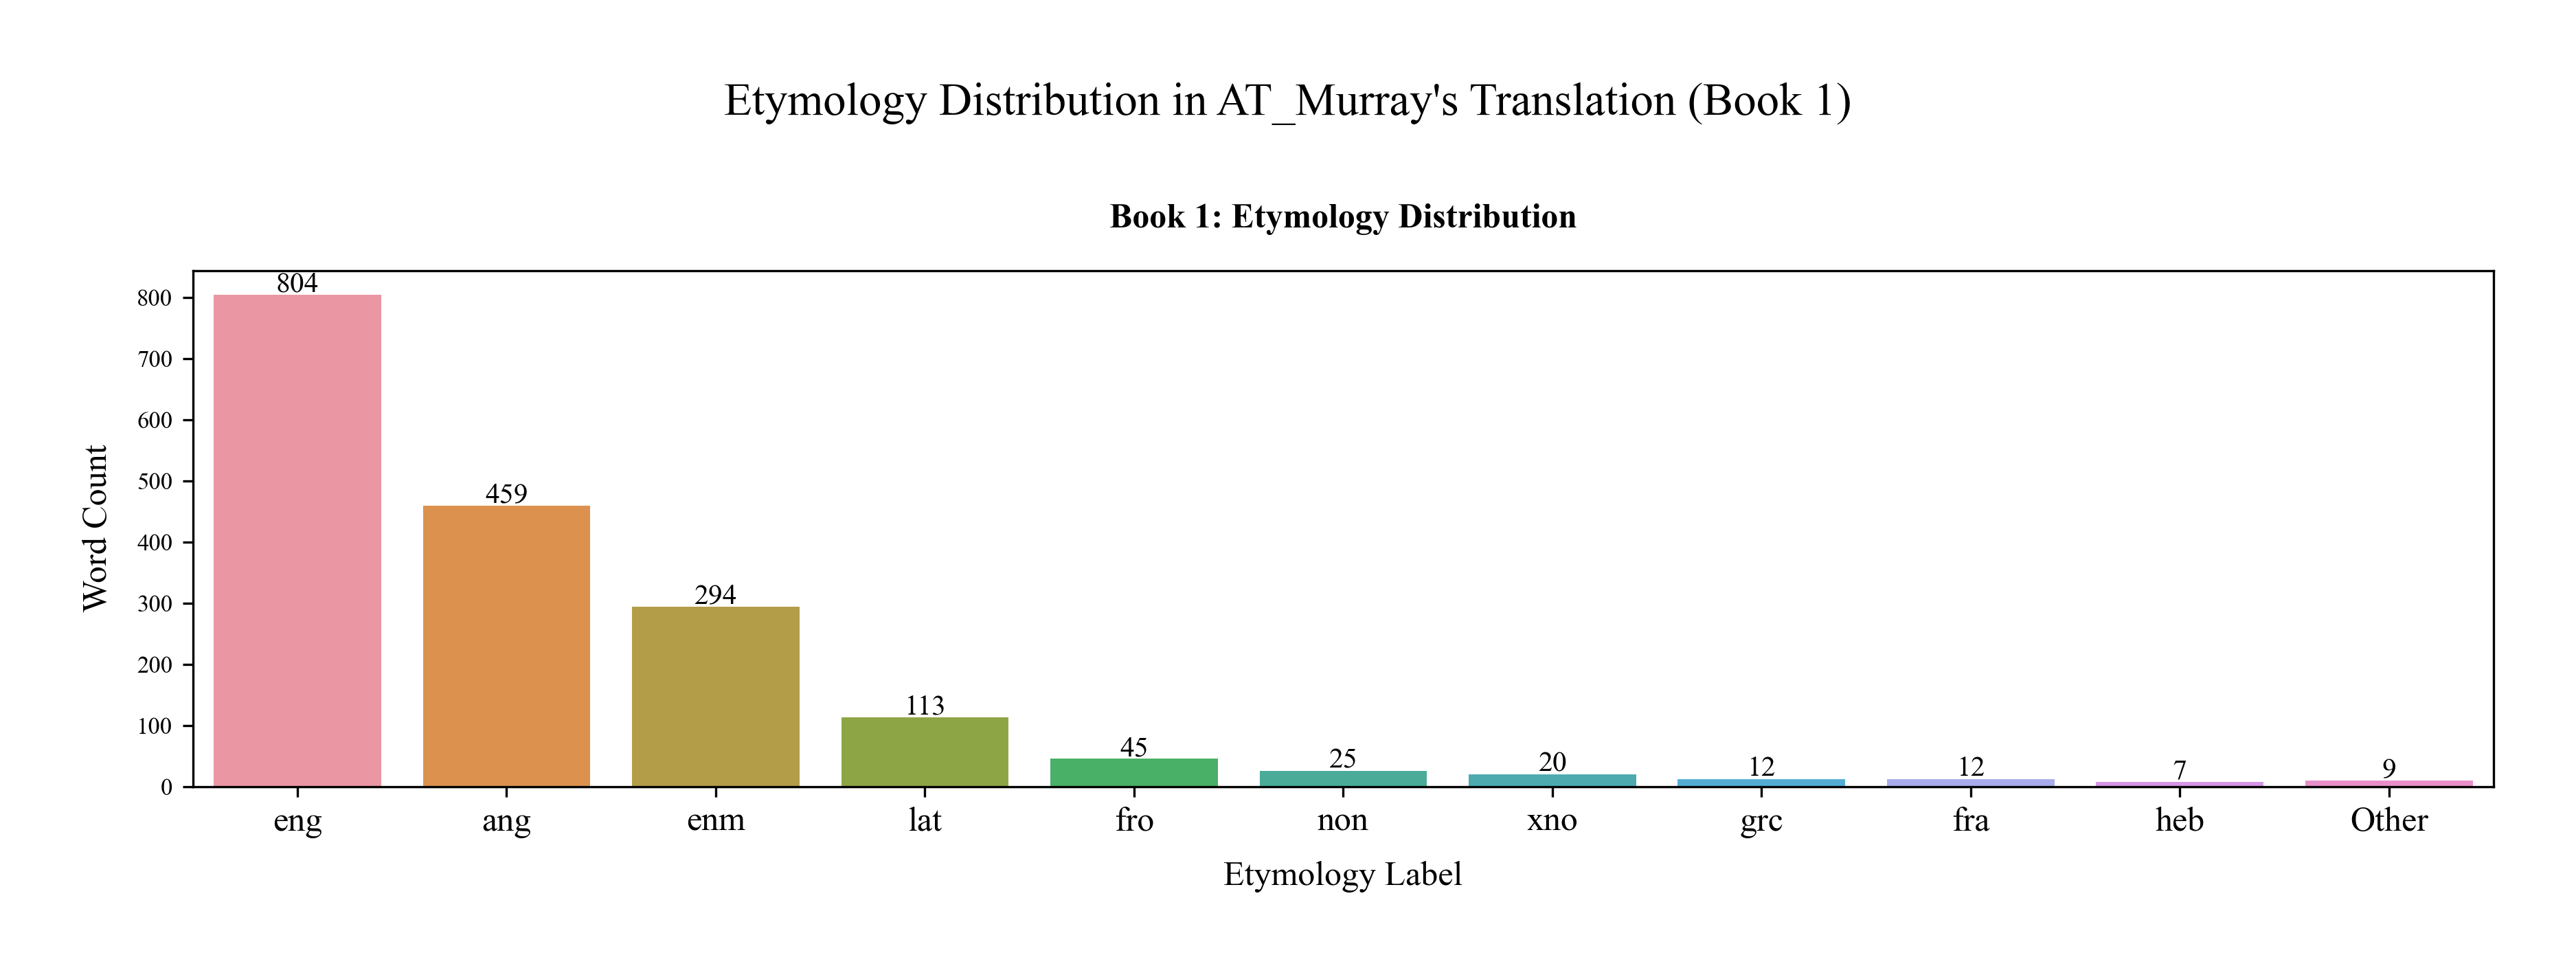

In [11]:
specific_colors = [chroma.color_palette["astroblue"], 
                   chroma.color_palette["orange"], 
                   chroma.color_palette["genoa"],
                   chroma.color_palette["carrot"], 
                   chroma.color_palette["tawny"],
                   chroma.color_palette["neptune"],
                   chroma.color_palette["jazzberry"],
                   chroma.color_palette["mako"]]

fig = oz.plot_etymology_counts(odysseys_df, "AT_Murray", 
                               book_range=1)

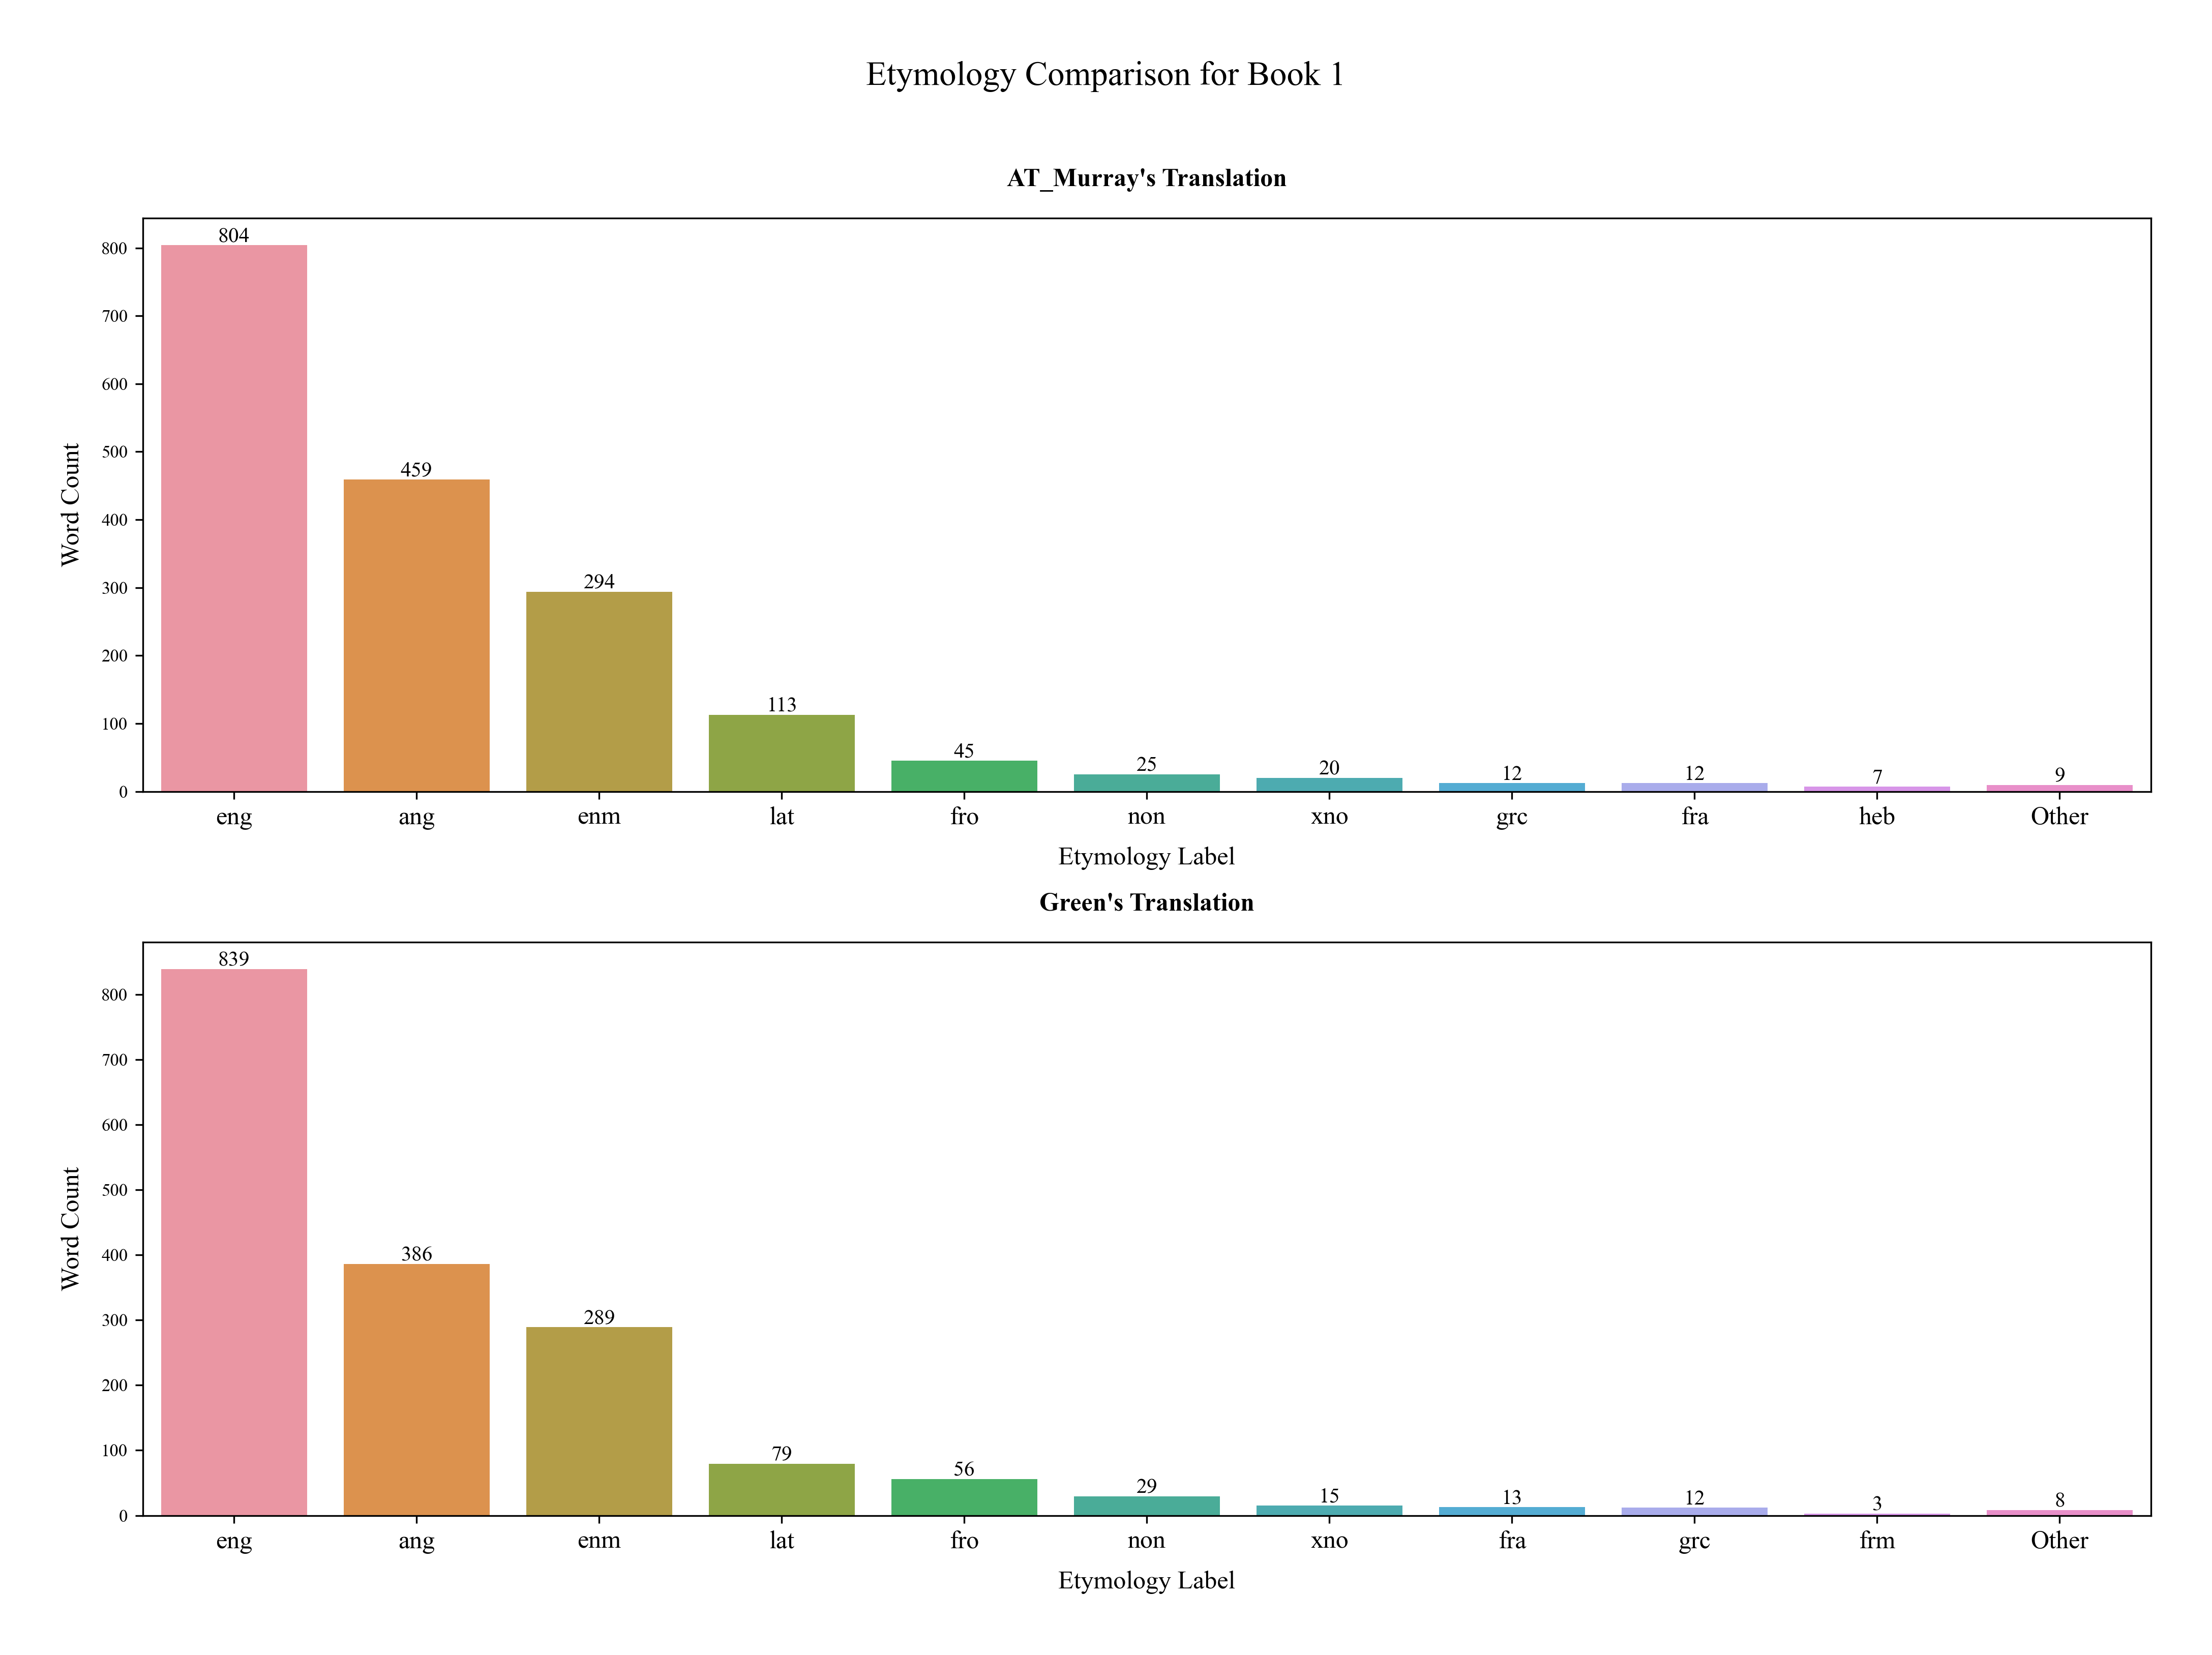

In [12]:

fig = oz.plot_etymology_comparison(odysseys_df, ["AT_Murray", "Green"], book_num=1)
fig.savefig(f"{output_path_plots}/ety_comparison_Murray_Butler_Pope_Book_1.png", dpi=300)


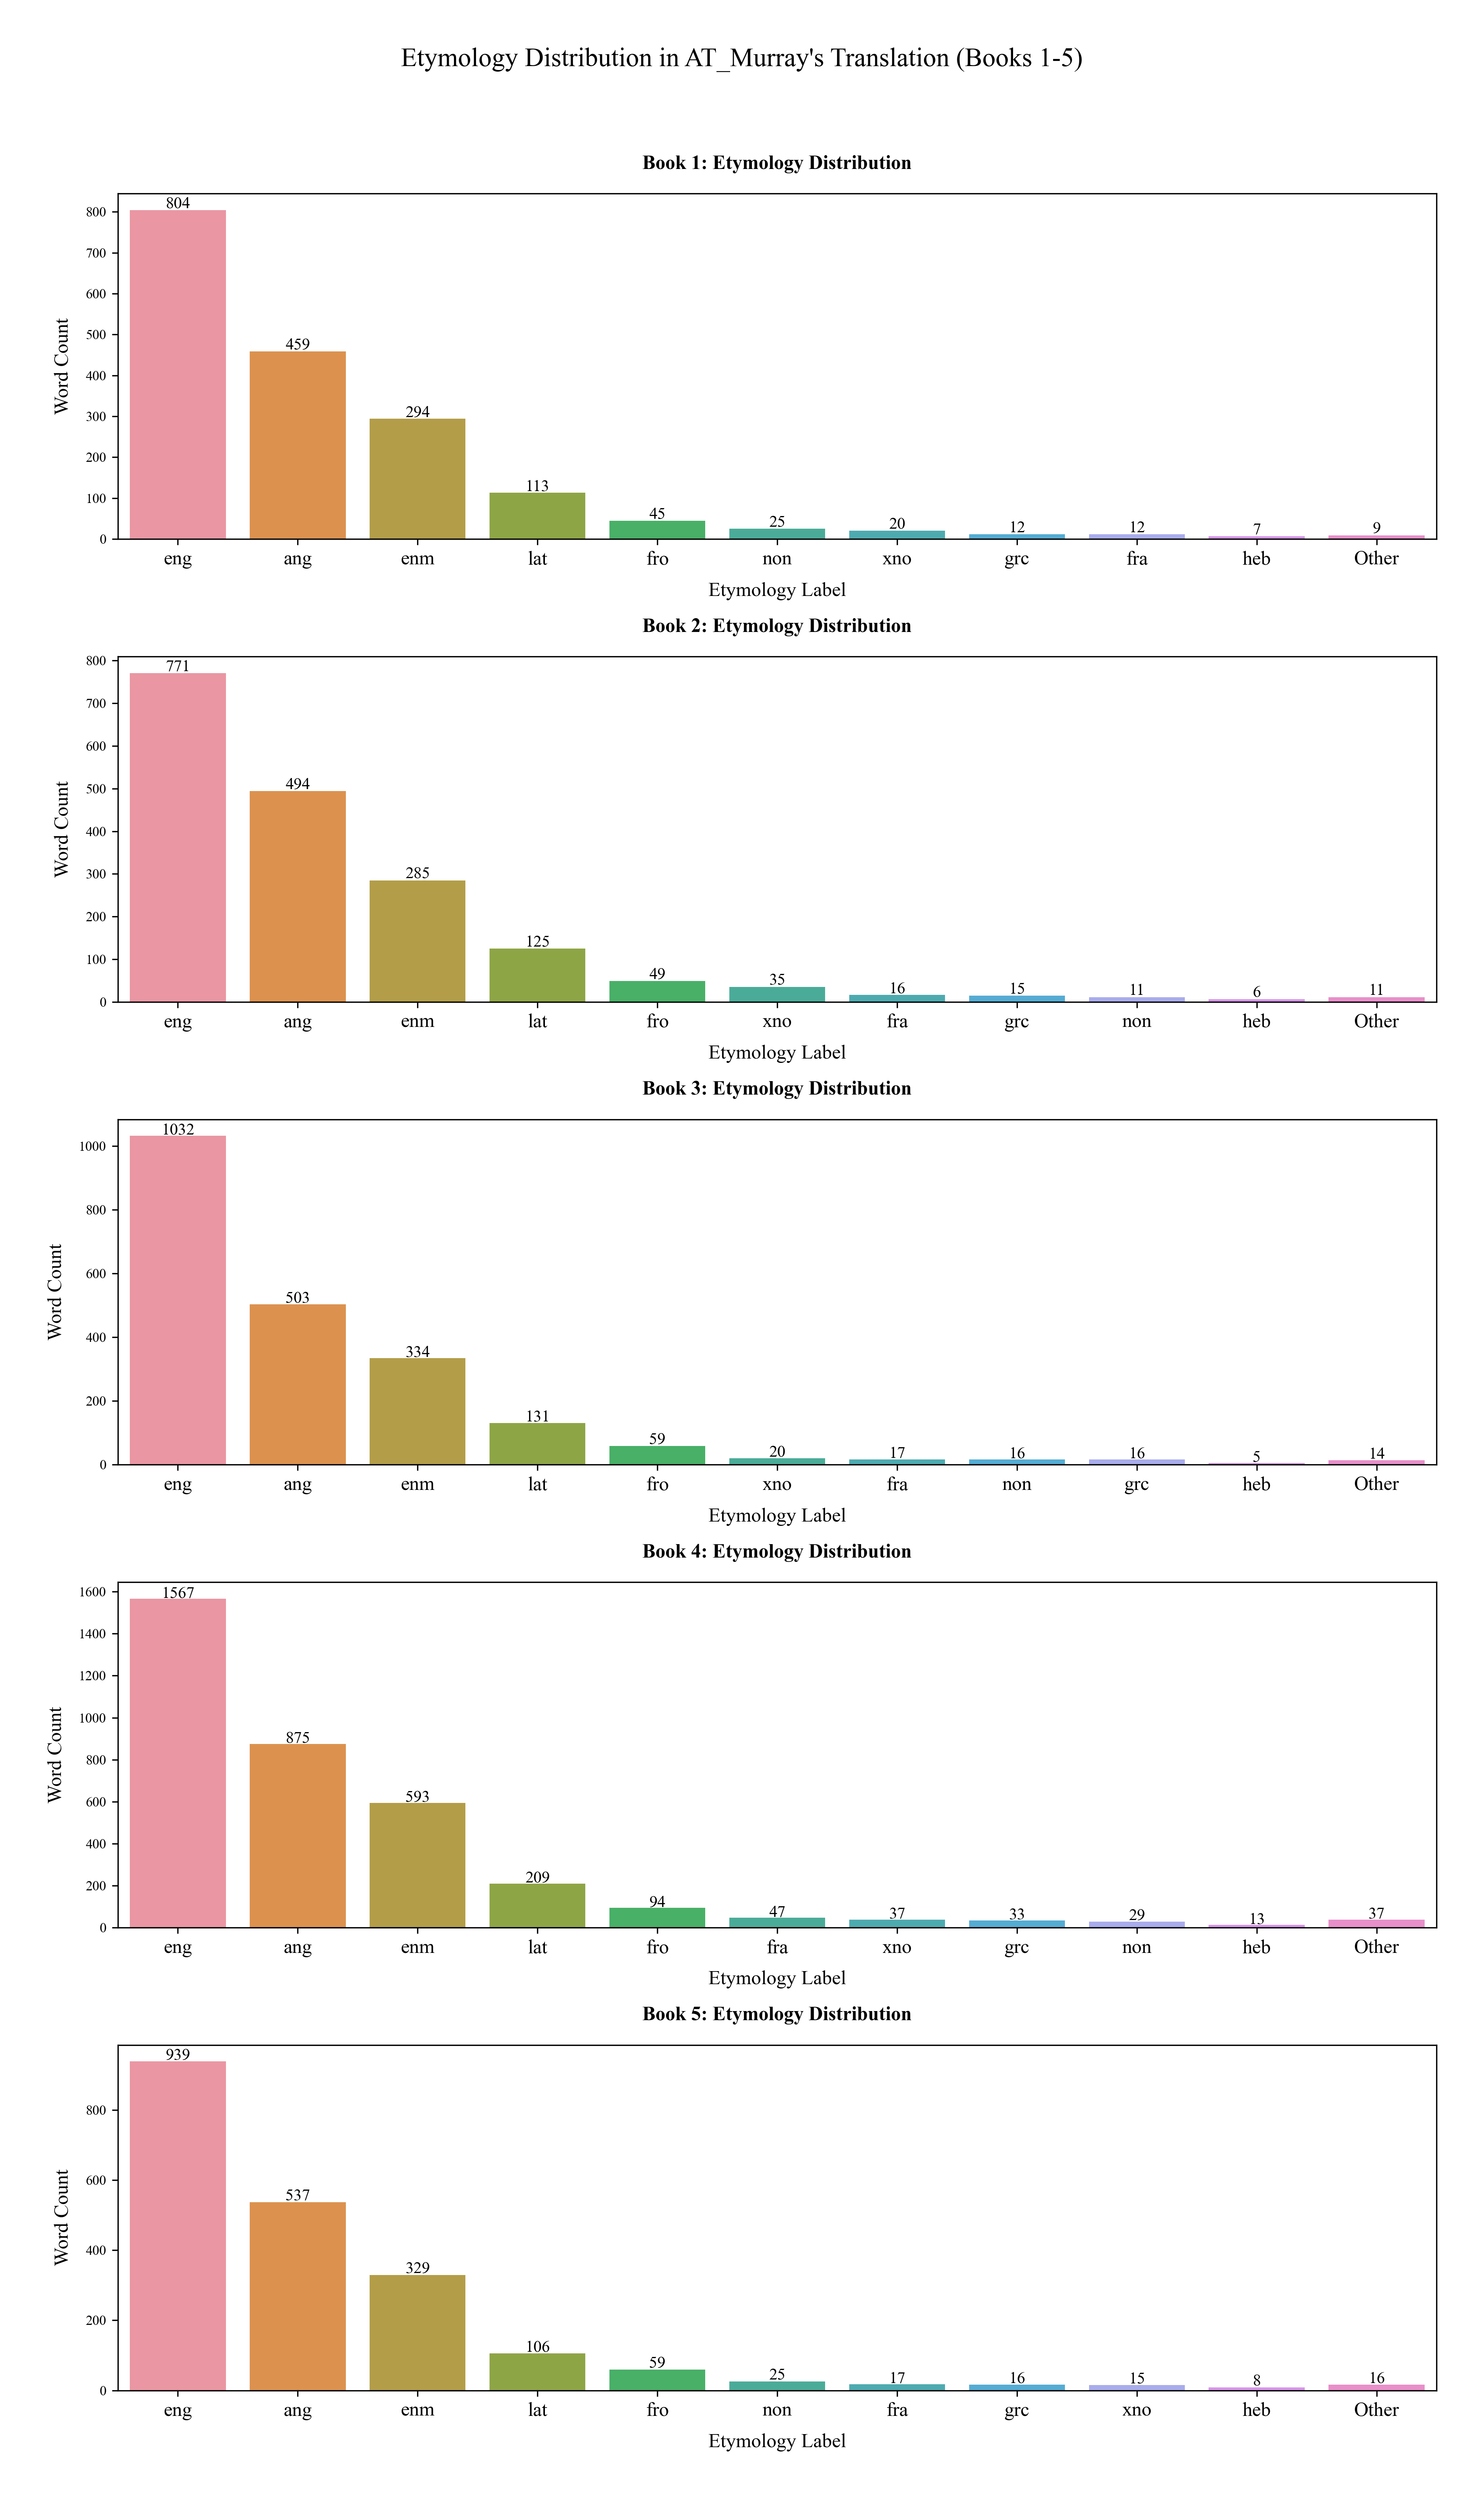

In [13]:
fig = oz.plot_etymology_counts(odysseys_df, "AT_Murray", book_range=(1, 5))

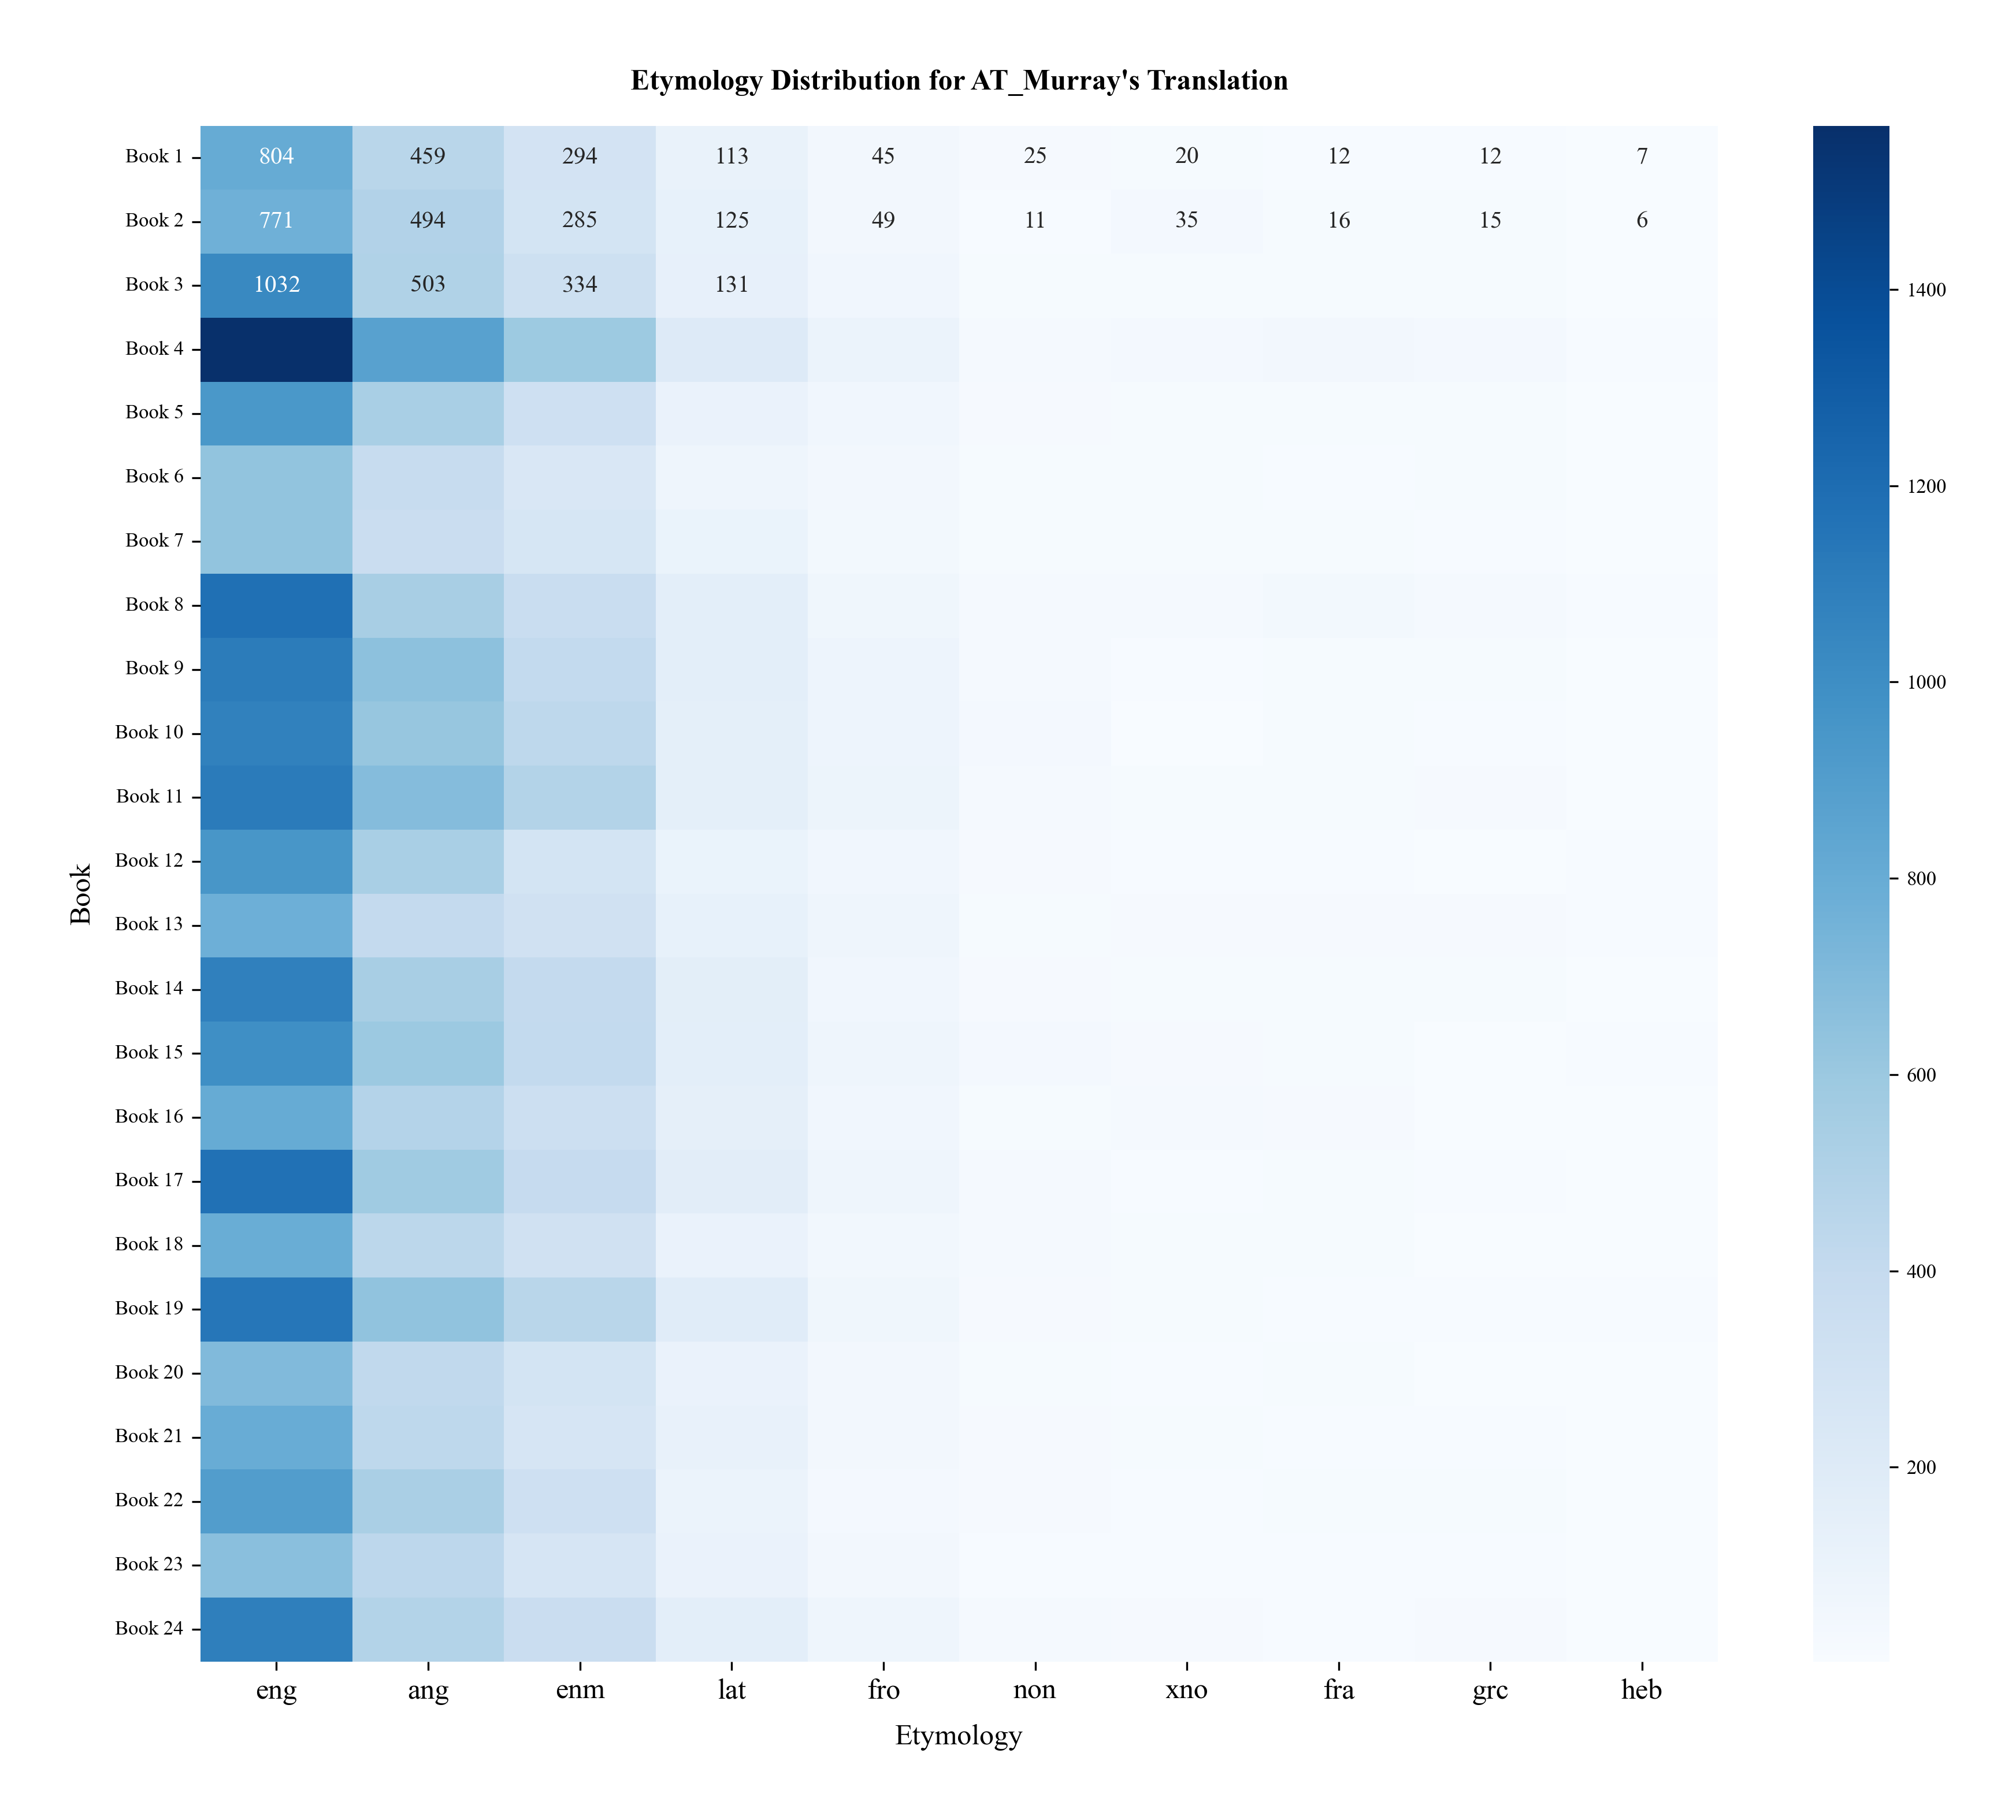

In [14]:
fig = oz.plot_etymology_heatmap(odysseys_df, "AT_Murray", book_range=(1, 24))

In [15]:
at_murray = odysseys_df[odysseys_df['translator'] == 'AT_Murray']
#at_murray_count = at_murray['ety_label_counts'].sum()
e.check_df(at_murray)

Mr righteous here has no missing values!

* df columns: Index(['translator', 'book_num', 'tokens', 'ety_labels', 'ety_label_counts'], dtype='object') 

* Shape: (24, 5) 

* Total memory in MB: 0.863103


In [16]:
Fitzgerald = odysseys_df[odysseys_df['translator'] == 'Fitzgerald']
plot_etymology_counts(Fitzgerald, translator_name='Fitzgerald', book_num=23, top_n=10)

NameError: name 'plot_etymology_counts' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def plot_aggregated_etymologies(df, translator_name='murray', top_n=20):
    """
    Aggregate etymology counts across all books for a specific translator
    and plot the top N most frequent etymologies.
    
    Parameters:
    df (DataFrame): The DataFrame containing the data
    translator_name (str): The name of the translator to filter by
    top_n (int): Number of top etymologies to display
    """
    # Filter for the specific translator
    translator_data = df[df['translator'] == translator_name]
    
    if len(translator_data) == 0:
        print(f"No data found for translator: {translator_name}")
        print(f"Available translators: {df['translator'].unique()}")
        return
    
    # Aggregate counts across all books
    aggregated_counts = Counter()
    
    for _, row in translator_data.iterrows():
        ety_counts = row['ety_label_counts']
        aggregated_counts.update(ety_counts)
    
    # Convert the aggregated counter to a DataFrame
    agg_df = pd.DataFrame(list(aggregated_counts.items()), columns=['Etymology', 'Count'])
    
    # Sort by count in descending order and get top N
    agg_df = agg_df.sort_values('Count', ascending=False).head(top_n)
    
    # Create the plot
    plt.figure(figsize=(14, 8))
    bar_plot = sns.barplot(x='Etymology', y='Count', data=agg_df, palette='viridis')
    
    # Customize the plot
    plt.title(f'Top {top_n} Etymologies in {translator_name.capitalize()}\'s Translation (All Books Combined)')
    plt.xlabel('Etymology Label')
    plt.ylabel('Word Count')
    plt.xticks(rotation=45, ha='right')
    
    # Add count labels on top of bars
    for i, v in enumerate(agg_df['Count']):
        plt.text(i, v + (max(agg_df['Count']) * 0.01), f'{v:,}', ha='center')
    
    # Add percentage labels
    total_words = agg_df['Count'].sum()
    for i, v in enumerate(agg_df['Count']):
        percentage = (v / total_words) * 100
        plt.text(i, v/2, f'{percentage:.1f}%', ha='center', color='white', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    return aggregated_counts

# Example usage
aggregated_counts = plot_aggregated_etymologies(at_murray, translator_name='AT_Murray', top_n=20)

# Optional: Print the total number of words analyzed
if aggregated_counts:
    total_words = sum(aggregated_counts.values())
    print(f"Total words analyzed: {total_words:,}")
    
    # Calculate and display etymology diversity metrics
    print(f"Number of distinct etymologies: {len(aggregated_counts)}")
    
    # Calculate percentage of words from the top 3 etymologies
    top_3 = sum(count for _, count in aggregated_counts.most_common(3))
    print(f"Percentage of words from top 3 etymologies: {(top_3/total_words)*100:.2f}%")